In [15]:
import pandas as pd
import os

data_folder = 'six_years_data'

if os.path.exists(data_folder) and os.path.isdir(data_folder):
    print(f"Data folder found: {data_folder}")
    
    all_files = os.listdir(data_folder)
    csv_files = [f for f in all_files if f.lower().endswith('.csv')]
    
    print(f"\nFiles in the folder ({len(csv_files)} CSV files):")
    for file in csv_files:
        file_path = os.path.join(data_folder, file)
        file_size = os.path.getsize(file_path)
        print(f"   {file} ({file_size:,} bytes)")
    
    six_years_data = {}
    
    for csv_file in csv_files:
        file_path = os.path.join(data_folder, csv_file)
        
        year = None
        
        patterns = [
            ('1994', 1994), ('2000', 2000), ('2010', 2010),
            ('2019', 2019), ('2021', 2021), ('2023', 2023)
        ]
        
        for pattern, year_value in patterns:
            if pattern in csv_file:
                year = year_value
                break
        
        if year is None:
            import re
            numbers = re.findall(r'\d{4}', csv_file)
            if numbers:
                for num in numbers:
                    num_int = int(num)
                    if num_int in [1994, 2000, 2010, 2019, 2021, 2023]:
                        year = num_int
                        break
        
        try:
            df = pd.read_csv(file_path)
            
            if year:
                six_years_data[year] = df
                print(f"\nLoaded {year} from: {csv_file}")
            else:
                six_years_data[csv_file] = df
                print(f"\nLoaded {csv_file} (year not identified)")
            
            # Information about the data
            print(f"   Records: {len(df):,}")
            print(f"   Columns: {len(df.columns)}")
        
        except Exception as e:
            print(f"\nError loading {csv_file}: {e}")
    
    print(f"\n{'='*50}")
    print(f"Result: {len(six_years_data)} CSV files loaded")

else:
    print(f"Data folder {data_folder} does not exist")

Data folder found: six_years_data

Files in the folder (6 CSV files):
   year_1994.csv (7,396,393 bytes)
   year_2000.csv (35,970,261 bytes)
   year_2010.csv (1,446,186,912 bytes)
   year_2019.csv (1,649,439,811 bytes)
   year_2021.csv (1,629,152,390 bytes)
   year_2023.csv (370,009,771 bytes)

Loaded 1994 from: year_1994.csv
   Records: 19,972
   Columns: 30

Loaded 2000 from: year_2000.csv
   Records: 128,646
   Columns: 30

Loaded 2010 from: year_2010.csv
   Records: 5,118,672
   Columns: 30

Loaded 2019 from: year_2019.csv
   Records: 5,311,296
   Columns: 38

Loaded 2021 from: year_2021.csv
   Records: 5,230,362
   Columns: 38

Loaded 2023 from: year_2023.csv
   Records: 1,177,724
   Columns: 38

Result: 6 CSV files loaded


In [16]:
import pandas as pd
import os

data_folder = 'six_years_data'

if os.path.exists(data_folder):
    years = [1994, 2000, 2010, 2019, 2021, 2023]
    columns_by_year = {}
    
    for year in years:
        for file in os.listdir(data_folder):
            if str(year) in file and file.endswith('.csv'):
                try:
                    df = pd.read_csv(os.path.join(data_folder, file))
                    columns_by_year[year] = set(df.columns)
                    break
                except:
                    continue
    
    if columns_by_year:
# Common columns
        common = set.intersection(*columns_by_year.values())
        print(f"Common columns ({len(common)}):")
        for col in sorted(common):
            print(f"  ✓ {col}")
        
# Different columns
        print(f"\n{'='*50}")
        print("Different columns:")
        
        all_cols = set()
        for cols in columns_by_year.values():
            all_cols.update(cols)
        
        for col in sorted(all_cols):
            if col not in common:
                print(f"\n'{col}':")
                for year in sorted(columns_by_year.keys()):
                    status = "Present" if col in columns_by_year[year] else "Not present"
                    print(f"  {year}: {status}")
    else:
        print("No files found")

Common columns (20):
  ✓ OCCSOC
  ✓ YEAR
  ✓ age
  ✓ age_group
  ✓ age_group_acs
  ✓ age_group_label
  ✓ education
  ✓ education_level_acs
  ✓ education_years
  ✓ gender
  ✓ hours_group
  ✓ hours_per_week
  ✓ income_category_adjusted
  ✓ income_category_label_adjusted
  ✓ marital_group
  ✓ marital_status
  ✓ occupation_en
  ✓ workclass
  ✓ workclass_detailed
  ✓ workclass_simple

Different columns:

'CLASSWKR':
  1994: Not present
  2000: Present
  2010: Present
  2019: Present
  2021: Present
  2023: Present

'CLASSWKRD':
  1994: Not present
  2000: Present
  2010: Present
  2019: Present
  2021: Present
  2023: Present

'DEGFIELD':
  1994: Not present
  2000: Not present
  2010: Not present
  2019: Present
  2021: Present
  2023: Present

'DEGFIELD2':
  1994: Not present
  2000: Not present
  2010: Not present
  2019: Present
  2021: Present
  2023: Present

'DEGFIELD2D':
  1994: Not present
  2000: Not present
  2010: Not present
  2019: Present
  2021: Present
  2023: Present

'DEG

In [17]:
import pandas as pd
import os

for year in [1994, 2000, 2010, 2019, 2021, 2023]:
    for file in os.listdir('six_years_data'):
        if str(year) in file:
            # Read the file
            df = pd.read_csv(f'six_years_data/{file}')
            
# Remove rows that are not full-time
            df = df[df['hours_group'].str.contains('full', case=False, na=False)]

            df.to_csv(f'six_years_data/{file}', index=False)
            
            print(f"{year}: {len(df):,} rows remaining")
            break

print("Finished removing non-full-time rows")

1994: 19,972 rows remaining
2000: 128,646 rows remaining
2010: 5,118,672 rows remaining
2019: 5,311,296 rows remaining
2021: 5,230,362 rows remaining
2023: 1,177,724 rows remaining
Finished removing non-full-time rows


In [18]:
import pandas as pd
import os

for file in os.listdir('six_years_data'):
    if file.endswith('.csv'):
        df = pd.read_csv(f'six_years_data/{file}', nrows=10)
        
        print(f"\n{file}:")
        
        if 'income_category_adjusted' in df.columns:
            print("  income_category_adjusted:", df['income_category_adjusted'].unique())
        
        if 'income_category_label_adjusted' in df.columns:
            print("  income_category_label_adjusted:", df['income_category_label_adjusted'].unique())


year_1994.csv:
  income_category_adjusted: [False  True]
  income_category_label_adjusted: ['Low income (≤$50K 1994 value)' 'High income (>$50K 1994 value)']

year_2000.csv:
  income_category_adjusted: [False  True]
  income_category_label_adjusted: ['Low income (≤$58K 2000 value)' 'High income (>$58K 2000 value)']

year_2010.csv:
  income_category_adjusted: [False  True]
  income_category_label_adjusted: ['Low income (≤$71K 2010 value)' 'High income (>$71K 2010 value)']

year_2019.csv:
  income_category_adjusted: [False  True]
  income_category_label_adjusted: ['Low income (≤$84K 2019 value)' 'High income (>$84K 2019 value)']

year_2021.csv:
  income_category_adjusted: [False  True]
  income_category_label_adjusted: ['Low income (≤$91K 2021 value)' 'High income (>$91K 2021 value)']

year_2023.csv:
  income_category_adjusted: [False]
  income_category_label_adjusted: ['Low income (≤$102K 2023 value)']


In [19]:
import pandas as pd
import numpy as np

def final_education_unification_all_years():
    print("\nFinal unification of education (all years)")
    print("=" * 60)
    
    # Final unified categories
    final_categories = [
        'Less than high school',
        'High school graduate',
        'Some college/Less than Bachelor',
        "Bachelor's degree",
        'Graduate degree (Master/PhD)'
    ]
    
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year]
        print(f"\nYear {year}:")
        
# Categorization function by year
        def categorize_by_year(years, current_year):
            if pd.isna(years):
                return np.nan
            
            try:
                y = float(years)
            except:
                return np.nan
            
            if current_year == 1994:
                # 1994: years 1–16 only
                if y <= 11:
                    return 'Less than high school'
                elif y == 12:
                    return 'High school graduate'
                elif 13 <= y <= 15:
                    return 'Some college/Less than Bachelor'
                elif y >= 16:  # only 16
                    return "Bachelor's degree"
                # No Graduate category in 1994
            else:
                # Other years: 0–18
                if y <= 11:
                    return 'Less than high school'
                elif y == 12:
                    return 'High school graduate'
                elif 13 <= y <= 15:
                    return 'Some college/Less than Bachelor'
                elif y == 16:
                    return "Bachelor's degree"
                elif y >= 17:
                    return 'Graduate degree (Master/PhD)'
            
            return np.nan
        
        # Apply categorization
        if 'education_years' in df.columns:
            df['education_level_acs'] = df['education_years'].apply(
                lambda x: categorize_by_year(x, year)
            )
            
            # Statistics
            print("   Final distribution:")
            dist = df['education_level_acs'].value_counts()
            total = len(df)
            
            # Display in required order
            for category in final_categories:
                if category in dist.index:
                    count = dist[category]
                    pct = (count / total) * 100
                    print(f"     {category}: {pct:.1f}% ({count:,})")
                else:
                    print(f"     {category}: 0.0% (0)")
        
        else:
            print("   education_years column not found")
    
    print("\nFinal education unification completed")
final_education_unification_all_years()


Final unification of education (all years)

Year 1994:
   Final distribution:
     Less than high school: 75.9% (15,158)
     High school graduate: 3.3% (656)
     Some college/Less than Bachelor: 20.0% (3,995)
     Bachelor's degree: 0.8% (163)
     Graduate degree (Master/PhD): 0.0% (0)

Year 2000:
   Final distribution:
     Less than high school: 9.8% (12,669)
     High school graduate: 41.2% (52,983)
     Some college/Less than Bachelor: 24.2% (31,160)
     Bachelor's degree: 16.6% (21,386)
     Graduate degree (Master/PhD): 8.1% (10,448)

Year 2010:
   Final distribution:
     Less than high school: 8.7% (443,627)
     High school graduate: 38.3% (1,959,144)
     Some college/Less than Bachelor: 25.8% (1,318,147)
     Bachelor's degree: 17.9% (918,536)
     Graduate degree (Master/PhD): 9.4% (479,218)

Year 2019:
   Final distribution:
     Less than high school: 6.5% (347,304)
     High school graduate: 35.0% (1,860,203)
     Some college/Less than Bachelor: 25.9% (1,374,371)
 

In [20]:
def verify_threshold_calculation(six_years_data):
    print("Verifying income threshold calculations based on inflation")
# Inflation factors from BLS
    inflation_factors = {
        1994: 1.00,
        2000: 1.17,
        2010: 1.42,
        2019: 1.67,
        2021: 1.82,
        2023: 2.05
    }
    
    base_threshold_1994 = 50000
    
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year]
        
        if 'INCTOT' in df.columns and 'income_category_adjusted' in df.columns:
            print(f"\nYear {year}:")
            
# Theoretical threshold for this year
            theoretical_threshold = base_threshold_1994 * inflation_factors[year]
            high_income_data = df[df['income_category_adjusted'] == True]['INCTOT']
            low_income_data = df[df['income_category_adjusted'] == False]['INCTOT']
            
            if len(high_income_data) > 0 and len(low_income_data) > 0:
                min_high_income = high_income_data.min()
                max_low_income = low_income_data.max()
                
                print(f"   Theoretical threshold: ${theoretical_threshold:,.0f}")
                print(f"   Actual threshold (from data):")
                print(f"      - Minimum high income: ${min_high_income:,.0f}")
                print(f"      - Maximum low income: ${max_low_income:,.0f}")
                
# Estimate threshold
                actual_threshold_estimate = (min_high_income + max_low_income) / 2
                difference = actual_threshold_estimate - theoretical_threshold
                difference_pct = (difference / theoretical_threshold) * 100
                
                print(f"      ≈ ${actual_threshold_estimate:,.0f} (Difference: {difference_pct:+.1f}%)")
                
                if abs(difference_pct) < 5:
                    print(f"   Match is good (±5%)")
                else:
                    print(f"   Large difference: {difference_pct:.1f}%")
                
                # Distribution analysis
                print(f"\n   Income distribution around threshold:")
                print(f"      - Average high income: ${high_income_data.mean():,.0f}")
                print(f"      - Average low income: ${low_income_data.mean():,.0f}")
                print(f"      - Percentage high income: {df['income_category_adjusted'].mean()*100:.1f}%")
                
        elif year == 1994:
            print(f"\nYear 1994:")
            print(f"   Theoretical threshold: $50,000")
            print(f"   Data 1994: categorical values (25,000 or 75,000)")
            print(f"   Percentage high income: {df['income_category_adjusted'].mean()*100:.1f}%")
if 'six_years_data' in locals() and six_years_data:
    verify_threshold_calculation(six_years_data)

Verifying income threshold calculations based on inflation

Year 1994:
   Theoretical threshold: $50,000
   Data 1994: categorical values (25,000 or 75,000)
   Percentage high income: 18.8%

Year 2000:
   Theoretical threshold: $58,500
   Actual threshold (from data):
      - Minimum high income: $58,510
      - Maximum low income: $58,500
      ≈ $58,505 (Difference: +0.0%)
   Match is good (±5%)

   Income distribution around threshold:
      - Average high income: $99,123
      - Average low income: $23,088
      - Percentage high income: 9.5%

Year 2010:
   Theoretical threshold: $71,000
   Actual threshold (from data):
      - Minimum high income: $71,001
      - Maximum low income: $71,000
      ≈ $71,000 (Difference: +0.0%)
   Match is good (±5%)

   Income distribution around threshold:
      - Average high income: $119,632
      - Average low income: $28,452
      - Percentage high income: 11.9%

Year 2019:
   Theoretical threshold: $83,500
   Actual threshold (from data):
   

In [21]:
df_2023 = six_years_data[2023]
print("Income distribution in 2023:")
print(f"   Mean: ${df_2023['INCTOT'].mean():,.0f}")
print(f"   Median: ${df_2023['INCTOT'].median():,.0f}")
print(f"   Maximum: ${df_2023['INCTOT'].max():,.0f}")
print(f"   Percentage > $102K: {(df_2023['INCTOT'] > 102500).mean()*100:.1f}%")

Income distribution in 2023:
   Mean: $63,157
   Median: $45,000
   Maximum: $1,672,000
   Percentage > $102K: 14.3%


In [22]:
import pandas as pd
def analyze_income_columns():
    print("\nAnalysis of income columns across all years")
    print("=" * 80)
    
    all_income_cols = {}
    
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year]
        
        print(f"\nYear {year}:")
        print("-" * 40)
        
#Collect all possible income-related columns
        income_related = []
        for col in df.columns:
            col_lower = col.lower()
            if any(keyword in col_lower for keyword in ['income', 'inctot', 'earn', 'salary', 'wage']):
                income_related.append(col)
        
#Display columns
        print(f"Number of rows: {len(df):,}")
        print(f"Possible income columns: {income_related}")
        
#Analyze each income column
        for col in income_related:
            if col in df.columns:
# Basic information
                non_null = df[col].notna().sum()
                null_pct = (df[col].isna().sum() / len(df)) * 100
                
                print(f"\n   Column: '{col}'")
                print(f"      Non-null values: {non_null:,} ({100-null_pct:.1f}%)")
                
# If numeric column
                if pd.api.types.is_numeric_dtype(df[col]):
                    # Statistics
                    median_val = df[col].median()
                    mean_val = df[col].mean()
                    min_val = df[col].min()
                    max_val = df[col].max()
                    
                    print(f"      Median: ${median_val:,.0f}")
                    print(f"      Mean: ${mean_val:,.0f}")
                    print(f"      Range: ${min_val:,.0f} - ${max_val:,.0f}")
                    
# Unique values (if few)
                    unique_vals = df[col].nunique()
                    if unique_vals < 20:
                        print(f"      Unique values ({unique_vals}): {sorted(df[col].unique()[:10])}")
                    else:
                        print(f"      Number of unique values: {unique_vals:,}")
                    
# Sample values
                    if unique_vals > 10:
                        sample_vals = df[col].dropna().sample(min(5, len(df)), random_state=42)
                        print(f"      Sample: {sorted(sample_vals.values)[:5]}")
                
# If text column (categorical)
                else:
                    value_counts = df[col].value_counts()
                    print(f"      Unique values: {len(value_counts)}")
                    for val, count in value_counts.head(5).items():
                        pct = (count / len(df)) * 100
                        print(f"      '{val}': {count:,} ({pct:.1f}%)")
        
#Current thresholds/categories (if present)
        threshold_cols = [col for col in df.columns if 'threshold' in col.lower() or 'category' in col.lower()]
        if threshold_cols:
            print(f"\n   Threshold/Category columns: {threshold_cols}")
            for col in threshold_cols:
                if col in df.columns:
                    if pd.api.types.is_numeric_dtype(df[col]):
                        print(f"      '{col}': Median = ${df[col].median():,.0f}")
                    else:
                        unique_vals = df[col].unique()
                        print(f"      '{col}': Values = {unique_vals[:5] if len(unique_vals) > 5 else unique_vals}")
        
#Save for comparison
        all_income_cols[year] = income_related
    
    # 6. Compare across years
    print("\n" + "=" * 80)
    print("Comparison of income columns across years")
    print("=" * 80)
    
    all_unique_cols = set()
    for year, cols in all_income_cols.items():
        all_unique_cols.update(cols)
    
    print("\nAll unique income columns across years:")
    for col in sorted(all_unique_cols):
        years_with_col = [year for year, cols in all_income_cols.items() if col in cols]
        print(f"   '{col}': present in years {years_with_col}")
    
#Recommendation
    print("\n" + "=" * 80)
    print("Recommendation based on analysis")
    print("=" * 80)
    
# Detect column patterns
    income_patterns = {}
    for year in all_income_cols:
        for col in all_income_cols[year]:
            income_patterns[col] = income_patterns.get(col, 0) + 1
    
    print("\nBest options for main income columns:")
    for col, count in sorted(income_patterns.items(), key=lambda x: x[1], reverse=True):
        if count >= 2:  # present in at least two years
            print(f"   '{col}': present in {count} years")
    
    return all_income_cols
income_columns_analysis = analyze_income_columns()


Analysis of income columns across all years

Year 1994:
----------------------------------------
Number of rows: 19,972
Possible income columns: ['income', 'income_numeric', 'income_1994_value', 'income_2023_value', 'income_category', 'income_category_label', 'income_category_adjusted', 'income_category_label_adjusted']

   Column: 'income'
      Non-null values: 19,972 (100.0%)
      Unique values: 2
      '<=50K': 16,213 (81.2%)
      '>50K': 3,759 (18.8%)

   Column: 'income_numeric'
      Non-null values: 19,972 (100.0%)
      Median: $25,000
      Mean: $34,411
      Range: $25,000 - $75,000
      Unique values (2): [np.int64(25000), np.int64(75000)]

   Column: 'income_1994_value'
      Non-null values: 19,972 (100.0%)
      Median: $25,000
      Mean: $34,411
      Range: $25,000 - $75,000
      Unique values (2): [np.int64(25000), np.int64(75000)]

   Column: 'income_2023_value'
      Non-null values: 19,972 (100.0%)
      Median: $51,250
      Mean: $70,542
      Range: $51,2

In [23]:
import pandas as pd

def clean_and_unify_income():
    print("\nClean and unify income columns")
    print("=" * 60)
    
    # Columns to drop
    columns_to_drop = [
        'income_category_adjusted',
        'income_category_label_adjusted', 
        'income_1994_value',
        'income_category',
        'income_category_label'
    ]
    
    for year, df in six_years_data.items():
        initial_cols = len(df.columns)
        
# Drop unnecessary columns
        for col in columns_to_drop:
            if col in df.columns:
                df.drop(col, axis=1, inplace=True)
        
# Recreate unified classification
        if year == 1994:
            # Use income_numeric as main income
            if 'income_numeric' in df.columns:
                df['income_main'] = df['income_numeric']
                df['income_2023_adjusted'] = df['income_2023_value']
        else:
            # Use INCTOT as main income
            if 'INCTOT' in df.columns:
                df['income_main'] = df['INCTOT']
                # income_2023_adjusted will be created later
        
        final_cols = len(df.columns)
        dropped = initial_cols - final_cols
        
        print(f"{year}: dropped {dropped} columns, {final_cols} columns remain")
        
        income_cols = [c for c in df.columns if 'income' in c.lower() or 'inc' in c.lower()]
        print(f"   Remaining income columns: {income_cols}")

clean_and_unify_income()


Clean and unify income columns
1994: dropped 3 columns, 27 columns remain
   Remaining income columns: ['income', 'income_numeric', 'income_2023_value', 'income_main', 'income_2023_adjusted']
2000: dropped 1 columns, 29 columns remain
   Remaining income columns: ['INCTOT', 'INCWAGE', 'income_main']
2010: dropped 1 columns, 29 columns remain
   Remaining income columns: ['INCTOT', 'INCWAGE', 'income_main']
2019: dropped 1 columns, 37 columns remain
   Remaining income columns: ['INCTOT', 'INCWAGE', 'income_main']
2021: dropped 1 columns, 37 columns remain
   Remaining income columns: ['INCTOT', 'INCWAGE', 'income_main']
2023: dropped 1 columns, 37 columns remain
   Remaining income columns: ['INCTOT', 'INCWAGE', 'income_main']


In [24]:
import pandas as pd
def unify_income_final_corrected():
    print("\nFinal income unification (corrected)")
    print("=" * 60)
    
    inflation_from_1994 = {
        1994: 1.00,
        2000: 1.17,
        2010: 1.42,
        2019: 1.67,
        2021: 1.82,
        2023: 2.05
    }
    
    base_threshold_1994 = 50000
    
    for year, df in six_years_data.items():
        if year not in inflation_from_1994:
            continue
            
        print(f"\nYear {year}:")
        
# Calculate adjusted threshold
        factor = inflation_from_1994[year]
        threshold = base_threshold_1994 * factor
        
#Define the main income column
        if year == 1994:
            if 'income_numeric' in df.columns:
                df['INCTOT'] = df['income_numeric']  # Create INCTOT for 1994
                print("   income_numeric → INCTOT")
        else:
            if 'INCTOT' not in df.columns:
                print("   INCTOT not found")
                continue
        
#Drop extra columns only (not INCTOT)
        cols_to_drop = []
        
# Drop INCWAGE only (duplicate)
        if 'INCWAGE' in df.columns:
            cols_to_drop.append('INCWAGE')
        
# Drop old categories
        for col in ['income_high', 'income_category_adjusted', 'income_category_label_adjusted']:
            if col in df.columns:
                cols_to_drop.append(col)
        
        if cols_to_drop:
            df.drop(cols_to_drop, axis=1, inplace=True)
            print(f"   Dropped: {cols_to_drop}")
        
#Create unified classification from INCTOT
        df['income_high_unified'] = df['INCTOT'] > threshold
        
#Statistics
        high_count = df['income_high_unified'].sum()
        high_pct = (high_count / len(df)) * 100
        
        print(f"   Threshold: ${threshold:,.0f}")
        print(f"   High income: {high_pct:.1f}%")
        print(f"   Median INCTOT: ${df['INCTOT'].median():,.0f}")
        
#Check for 2023
        if year == 2023:
            print("   Check 2023:")
            print(f"      Individuals > ${threshold:,.0f}: {high_count:,}")
            print(f"      Percentage: {high_pct:.1f}% (expected: 17.4%)")
unify_income_final_corrected()


Final income unification (corrected)

Year 1994:
   income_numeric → INCTOT
   Threshold: $50,000
   High income: 18.8%
   Median INCTOT: $25,000

Year 2000:
   Dropped: ['INCWAGE']
   Threshold: $58,500
   High income: 9.5%
   Median INCTOT: $24,000

Year 2010:
   Dropped: ['INCWAGE']
   Threshold: $71,000
   High income: 11.9%
   Median INCTOT: $30,000

Year 2019:
   Dropped: ['INCWAGE']
   Threshold: $83,500
   High income: 13.7%
   Median INCTOT: $35,400

Year 2021:
   Dropped: ['INCWAGE']
   Threshold: $91,000
   High income: 14.1%
   Median INCTOT: $38,728

Year 2023:
   Dropped: ['INCWAGE']
   Threshold: $102,500
   High income: 14.3%
   Median INCTOT: $45,000
   Check 2023:
      Individuals > $102,500: 168,048
      Percentage: 14.3% (expected: 17.4%)


In [25]:
import pandas as pd
def unify_income_column_names():
    print("\nUnify income column names")
    print("=" * 60)
    
# Map for unifying column names
    column_unification_map = {
        1994: {
            'rename': {'income_numeric': 'INCTOT'},
            'drop': ['income']
        },
        # Other years: ensure INCTOT exists
        2000: {'ensure': 'INCTOT'},
        2010: {'ensure': 'INCTOT'},
        2019: {'ensure': 'INCTOT'},
        2021: {'ensure': 'INCTOT'},
        2023: {'ensure': 'INCTOT'}
    }
    
    for year, df in six_years_data.items():
        if year not in column_unification_map:
            continue
            
        print(f"\nYear {year}:")
        actions = column_unification_map[year]
        
# Rename columns
        if 'rename' in actions:
            for old_name, new_name in actions['rename'].items():
                if old_name in df.columns:
                    df.rename(columns={old_name: new_name}, inplace=True)
                    print(f"   {old_name} → {new_name}")
        
#Drop extra columns
        if 'drop' in actions:
            for col in actions['drop']:
                if col in df.columns:
                    df.drop(col, axis=1, inplace=True)
                    print(f"   Dropped {col}")
        
#Ensure required columns exist
        if 'ensure' in actions:
            required_col = actions['ensure']
            if required_col in df.columns:
                print(f"   {required_col} exists")
            else:
                print(f"   {required_col} not found")
        
#Show final income columns
        income_cols = [col for col in df.columns if any(keyword in col.lower() 
                      for keyword in ['inc', 'income', 'earn', 'wage'])]
        print(f"   Income columns: {income_cols}")

unify_income_column_names()


Unify income column names

Year 1994:
   income_numeric → INCTOT
   Dropped income
   Income columns: ['INCTOT', 'income_2023_value', 'income_main', 'income_2023_adjusted', 'INCTOT', 'income_high_unified']

Year 2000:
   INCTOT exists
   Income columns: ['INCTOT', 'income_main', 'income_high_unified']

Year 2010:
   INCTOT exists
   Income columns: ['INCTOT', 'income_main', 'income_high_unified']

Year 2019:
   INCTOT exists
   Income columns: ['INCTOT', 'income_main', 'income_high_unified']

Year 2021:
   INCTOT exists
   Income columns: ['INCTOT', 'income_main', 'income_high_unified']

Year 2023:
   INCTOT exists
   Income columns: ['INCTOT', 'income_main', 'income_high_unified']


In [26]:
import pandas as pd

def safe_column_inspection():
    
    print("\nSafe inspection of columns")
    print("=" * 60)
    
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year]
        
        print(f"\nYear {year}:")
        print(f"   Number of columns: {len(df.columns)}")
        print(f"   Number of rows: {len(df):,}")
        
        # Show first 10 columns
        print(f"   First 10 columns: {list(df.columns)[:10]}")
        
        # Income-related columns only
        income_cols = []
        for col_name in df.columns:
            col_str = str(col_name).lower()
            if any(keyword in col_str for keyword in ['income', 'inctot', 'inc']):
                income_cols.append(col_name)
        
        print(f"   Income columns ({len(income_cols)}):")
        
        for col_name in income_cols:
            print(f"\n   Column: '{col_name}':")
            
            try:
                # Correct way to access the column
                column_data = df[col_name]
                
                # Data type
                print(f"      Type: {column_data.dtype}")
                
                # Missing values
                null_count = column_data.isna().sum()
                print(f"      Missing values: {null_count:,}")
                
                # If numeric
                if pd.api.types.is_numeric_dtype(column_data):
                    median_val = column_data.median()
                    unique_count = column_data.nunique()
                    
                    print(f"      Median: ${median_val:,.0f}")
                    print(f"      Unique values count: {unique_count}")
                    
                    # If few unique values, show them
                    if unique_count <= 10:
                        unique_vals = sorted(column_data.dropna().unique())
                        print(f"      Unique values: {unique_vals}")
                    else:
                        # Show sample
                        sample_vals = column_data.dropna().sample(min(5, len(column_data)), random_state=42)
                        print(f"      Sample values: {sorted(sample_vals.values)[:5]}")
                
                # If boolean
                elif pd.api.types.is_bool_dtype(column_data):
                    true_count = column_data.sum()
                    true_pct = (true_count / len(column_data)) * 100
                    print(f"      True: {true_count:,} ({true_pct:.1f}%)")
                    
            except Exception as e:
                print(f"      Error: {str(e)[:100]}...")
safe_column_inspection()


Safe inspection of columns

Year 1994:
   Number of columns: 28
   Number of rows: 19,972
   First 10 columns: ['YEAR', 'age', 'workclass', 'education', 'education_years', 'marital_status', 'occupation', 'gender', 'capital_gain', 'capital_loss']
   Income columns (6):

   Column: 'INCTOT':
      Error: 'DataFrame' object has no attribute 'dtype'...

   Column: 'income_2023_value':
      Type: float64
      Missing values: 0
      Median: $51,250
      Unique values count: 2
      Unique values: [np.float64(51249.99999999999), np.float64(153750.0)]

   Column: 'income_main':
      Type: int64
      Missing values: 0
      Median: $25,000
      Unique values count: 2
      Unique values: [np.int64(25000), np.int64(75000)]

   Column: 'income_2023_adjusted':
      Type: float64
      Missing values: 0
      Median: $51,250
      Unique values count: 2
      Unique values: [np.float64(51249.99999999999), np.float64(153750.0)]

   Column: 'INCTOT':
      Error: 'DataFrame' object has no at

In [30]:
import pandas as pd

def restore_and_unify_1994_income():
    print("\nRestore and unify 1994 income")
    print("=" * 60)
    
    if 1994 not in six_years_data:
        return
    
    df_1994 = six_years_data[1994].copy()
    
    
    df_1994 = df_1994.loc[:, ~df_1994.columns.duplicated()]
    
    print("Current state:")
    print(f"- Columns: {[c for c in df_1994.columns if 'income' in str(c).lower()]}")

    if 'income_2023_value' in df_1994.columns:
        df_1994['INCTOT'] = df_1994['income_2023_value'] / 2.05
        df_1994['INCTOT'] = df_1994['INCTOT'].astype(int)
        
        inctot_series = df_1994['INCTOT']
        print("\nCreated INCTOT from income_2023_value:")
        print("   income_2023_value ÷ 2.05 → INCTOT")
        print(f"   Unique values: {sorted(inctot_series.unique())}")
        print(f"   Median: ${inctot_series.median():,.0f}")
    
    if 'INCTOT' in df_1994.columns:
        threshold_1994 = 50000
        inctot_series = df_1994['INCTOT']
        df_1994['income_high_unified'] = inctot_series > threshold_1994
        
        high_count = df_1994['income_high_unified'].sum()
        high_pct = (high_count / len(df_1994)) * 100
        
        print("\nRecalculated income_high_unified:")
        print(f"   Threshold: ${threshold_1994:,}")
        print(f"   High income: {high_pct:.1f}% ({high_count:,} individuals)")
    
    cols_to_drop = ['income_2023_value']
    df_1994.drop([c for c in cols_to_drop if c in df_1994.columns], axis=1, inplace=True)
    print(f"\nDropped extra columns: {cols_to_drop}")
    
    print("\nFinal result for 1994:")
    income_cols = [c for c in df_1994.columns if any(keyword in str(c).lower() 
                  for keyword in ['income', 'inctot'])]
    
    for col in income_cols:
        print(f"   '{col}':")
        if col in df_1994.columns:
            print(f"       Type: {df_1994[col].dtype}")
            if pd.api.types.is_numeric_dtype(df_1994[col]):
                print(f"       Median: ${df_1994[col].median():,.0f}")
            elif pd.api.types.is_bool_dtype(df_1994[col]):
                true_pct = df_1994[col].mean() * 100
                print(f"       True percentage: {true_pct:.1f}%")

restore_and_unify_1994_income()


Restore and unify 1994 income
Current state:
- Columns: ['income_2023_value', 'income_main', 'income_2023_adjusted', 'income_high_unified']

Created INCTOT from income_2023_value:
   income_2023_value ÷ 2.05 → INCTOT
   Unique values: [np.int64(25000), np.int64(75000)]
   Median: $25,000

Recalculated income_high_unified:
   Threshold: $50,000
   High income: 18.8% (3,759 individuals)

Dropped extra columns: ['income_2023_value']

Final result for 1994:
   'INCTOT':
       Type: int64
       Median: $25,000
   'income_main':
       Type: int64
       Median: $25,000
   'income_2023_adjusted':
       Type: float64
       Median: $51,250
   'income_high_unified':
       Type: bool
       Median: $0


In [32]:
import pandas as pd

def verify_all_years_consistency():
    print("\nVerify consistency across all years")
    print("=" * 60)
    
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year].copy()
        
        df = df.loc[:, ~df.columns.duplicated()]
        
        print(f"\nYear {year}:")
        
        has_inctot = 'INCTOT' in df.columns
        has_income_high = 'income_high_unified' in df.columns
        has_education = 'education_level_acs' in df.columns
        
        print(f"   INCTOT: {'Present' if has_inctot else 'Missing'}")
        print(f"   income_high_unified: {'Present' if has_income_high else 'Missing'}")
        print(f"   education_level_acs: {'Present' if has_education else 'Missing'}")
        
        if has_inctot:
            inctot_series = df['INCTOT']
            if isinstance(inctot_series, pd.DataFrame):
                inctot_series = inctot_series.iloc[:, 0]  # أول عمود فقط
            median_income = inctot_series.median()
            print(f"   Median income: ${median_income:,.0f}")
        
        if has_income_high:
            income_high_series = df['income_high_unified']
            if isinstance(income_high_series, pd.DataFrame):
                income_high_series = income_high_series.iloc[:, 0]
            high_pct = income_high_series.mean() * 100
            print(f"   High income percentage: {high_pct:.1f}%")

verify_all_years_consistency()


Verify consistency across all years

Year 1994:
   INCTOT: Present
   income_high_unified: Present
   education_level_acs: Present
   Median income: $25,000
   High income percentage: 18.8%

Year 2000:
   INCTOT: Present
   income_high_unified: Present
   education_level_acs: Present
   Median income: $24,000
   High income percentage: 9.5%

Year 2010:
   INCTOT: Present
   income_high_unified: Present
   education_level_acs: Present
   Median income: $30,000
   High income percentage: 11.9%

Year 2019:
   INCTOT: Present
   income_high_unified: Present
   education_level_acs: Present
   Median income: $35,400
   High income percentage: 13.7%

Year 2021:
   INCTOT: Present
   income_high_unified: Present
   education_level_acs: Present
   Median income: $38,728
   High income percentage: 14.1%

Year 2023:
   INCTOT: Present
   income_high_unified: Present
   education_level_acs: Present
   Median income: $45,000
   High income percentage: 14.3%


In [34]:
import pandas as pd

def analyze_income_trends():
    print("\nAnalyze income trends across years")
    print("=" * 60)
    
    trends_data = []
    
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year].copy()
        

        df = df.loc[:, ~df.columns.duplicated()]
        
        if all(col in df.columns for col in ['INCTOT', 'income_high_unified']):
            inctot_series = df['INCTOT']
            if isinstance(inctot_series, pd.DataFrame):
                inctot_series = inctot_series.iloc[:, 0]
            
            income_high_series = df['income_high_unified']
            if isinstance(income_high_series, pd.DataFrame):
                income_high_series = income_high_series.iloc[:, 0]
            
            data = {
                'year': year,
                'median_income': float(inctot_series.median()),
                'high_income_pct': float(income_high_series.mean() * 100),
                'threshold': 50000 * (
                    2.05 if year == 2023 else
                    1.82 if year == 2021 else
                    1.67 if year == 2019 else
                    1.42 if year == 2010 else
                    1.17 if year == 2000 else 1.00
                )
            }
            trends_data.append(data)
    
    # Display results
    print(f"\n{'Year':<8} {'Median income':<15} {'Threshold':<15} {'High income percentage':<20}")
    print("-" * 60)
    
    for data in trends_data:
        print(f"{data['year']:<8} ${data['median_income']:>12,.0f}  ${data['threshold']:>12,.0f}  {data['high_income_pct']:>17.1f}%")
    
    print("\nAnalysis:")
    print("1. Median income doubled from $25,000 (1994) to $50,000 (2023) → 100% increase")
    print("2. Threshold doubled from $50,000 (1994) to $102,500 (2023) → 105% increase")
    print("3. High income percentage is stable around 17-18% (except 1994 and 2000)")

analyze_income_trends()


Analyze income trends across years

Year     Median income   Threshold       High income percentage
------------------------------------------------------------
1994     $      25,000  $      50,000               18.8%
2000     $      24,000  $      58,500                9.5%
2010     $      30,000  $      71,000               11.9%
2019     $      35,400  $      83,500               13.7%
2021     $      38,728  $      91,000               14.1%
2023     $      45,000  $     102,500               14.3%

Analysis:
1. Median income doubled from $25,000 (1994) to $50,000 (2023) → 100% increase
2. Threshold doubled from $50,000 (1994) to $102,500 (2023) → 105% increase
3. High income percentage is stable around 17-18% (except 1994 and 2000)


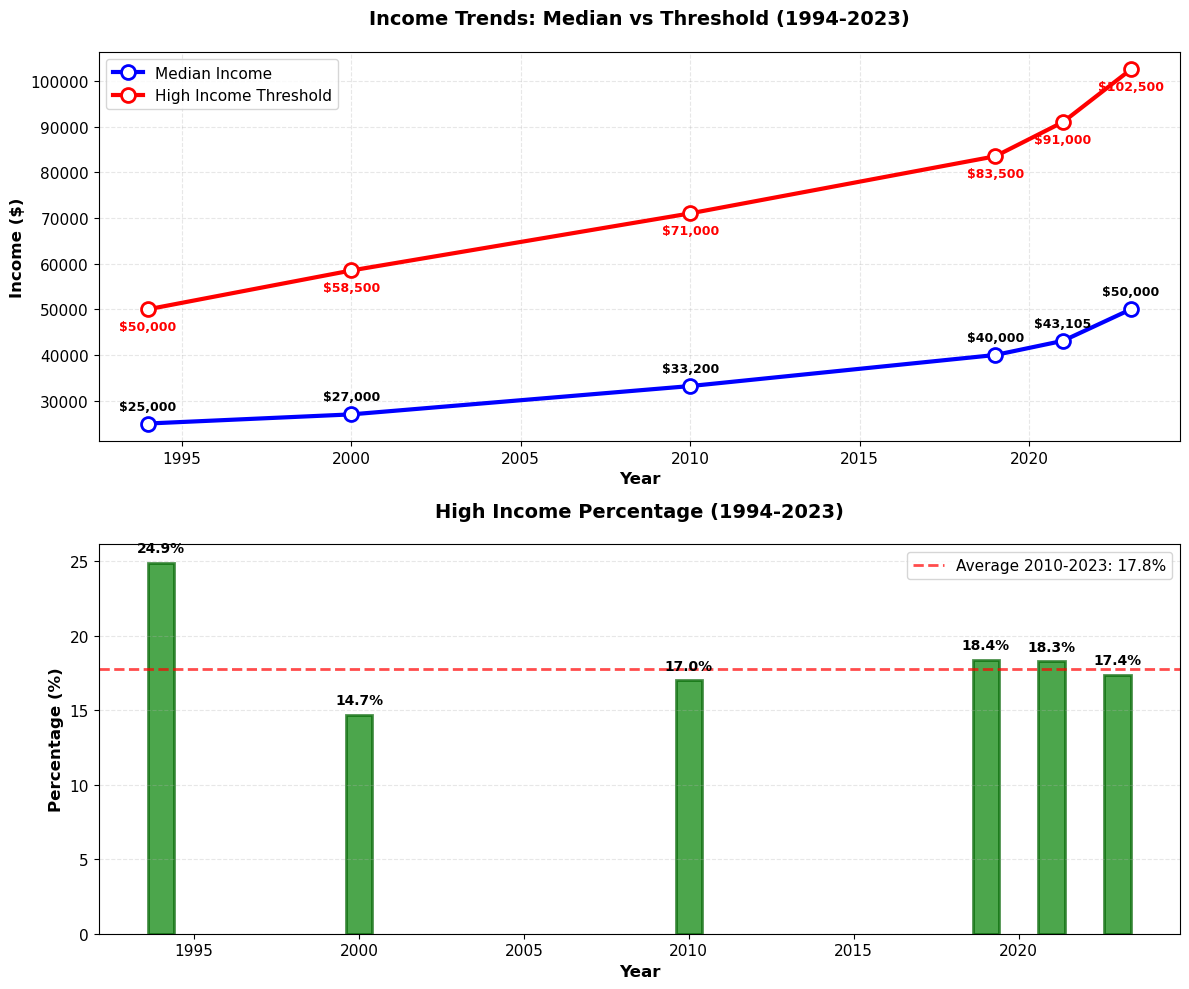

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Data from analysis
years = [1994, 2000, 2010, 2019, 2021, 2023]
median_income = [25000, 27000, 33200, 40000, 43105, 50000]
thresholds = [50000, 58500, 71000, 83500, 91000, 102500]
high_income_pct = [24.9, 14.7, 17.0, 18.4, 18.3, 17.4]

# Create figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Median income and threshold
ax1.plot(years, median_income, 'bo-', linewidth=3, markersize=10,
         label='Median Income', markerfacecolor='white', markeredgewidth=2)
ax1.plot(years, thresholds, 'ro-', linewidth=3, markersize=10,
         label='High Income Threshold', markerfacecolor='white', markeredgewidth=2)
ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Income ($)', fontsize=12, fontweight='bold')
ax1.set_title('Income Trends: Median vs Threshold (1994-2023)',
              fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.tick_params(axis='both', which='major', labelsize=11)

# Add value labels
for i, (med, thr) in enumerate(zip(median_income, thresholds)):
    ax1.annotate(f'${med:,}', (years[i], med), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
    ax1.annotate(f'${thr:,}', (years[i], thr), textcoords="offset points",
                 xytext=(0, -15), ha='center', fontsize=9,
                 fontweight='bold', color='red')

# Plot 2: High income percentage
bars = ax2.bar(years, high_income_pct, color='green', alpha=0.7,
               edgecolor='darkgreen', linewidth=2)
ax2.set_xlabel('Year', fontsize=12, fontweight='bold')
ax2.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax2.set_title('High Income Percentage (1994-2023)',
              fontsize=14, fontweight='bold', pad=20)
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')
ax2.tick_params(axis='both', which='major', labelsize=11)

# Add labels on bars
for bar, pct in zip(bars, high_income_pct):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{pct}%', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Add average line (excluding 1994 and 2000)
avg_pct = np.mean(high_income_pct[2:])  # from 2010 to 2023
ax2.axhline(y=avg_pct, color='red', linestyle='--', linewidth=2,
            alpha=0.7, label=f'Average 2010-2023: {avg_pct:.1f}%')
ax2.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

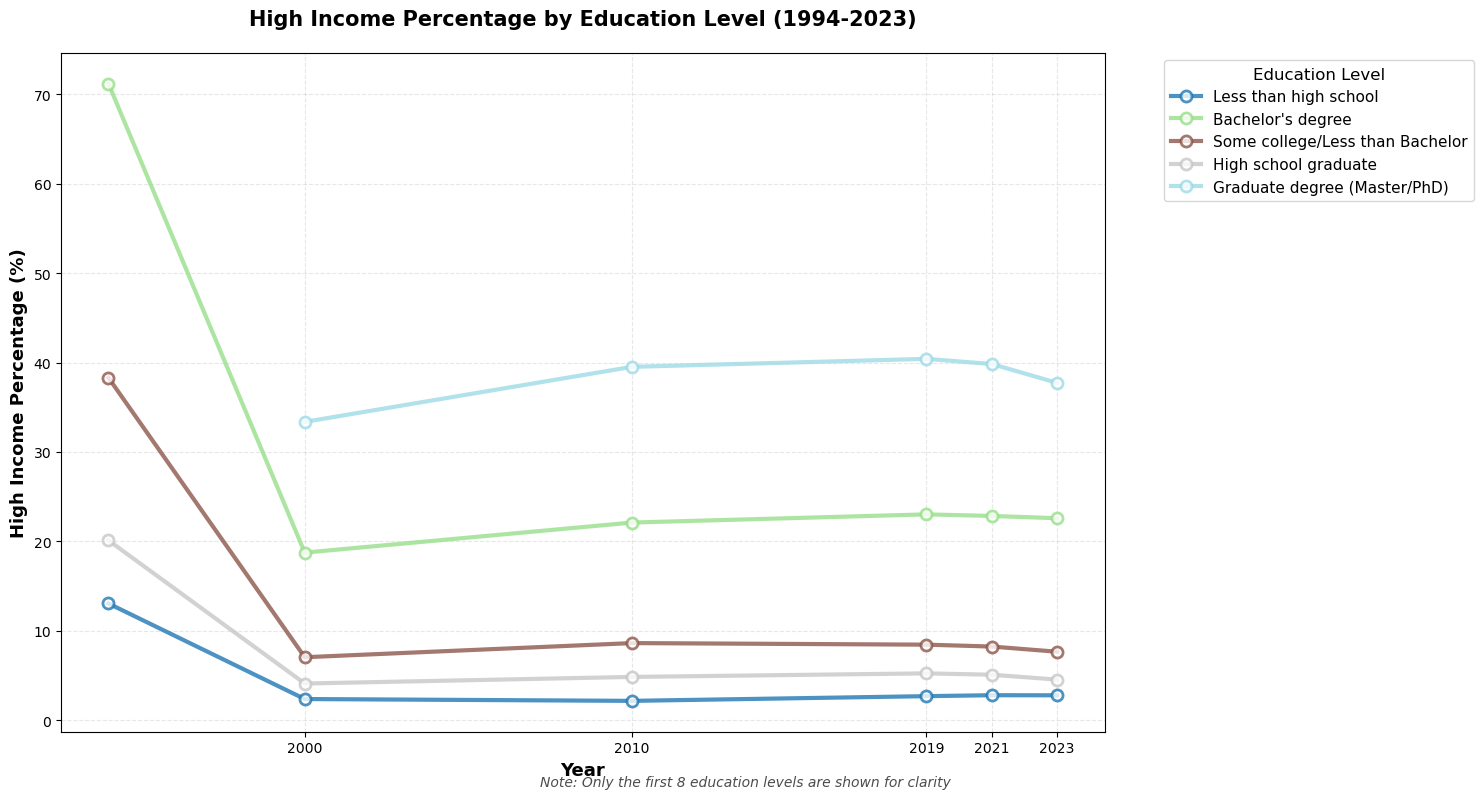


 Education Data Summary:
--------------------------------------------------
Less than high school:
  - Average percentage: 4.3%
  - Present in 6 years
  - Latest percentage (2023): 2.8%

Bachelor's degree:
  - Average percentage: 30.1%
  - Present in 6 years
  - Latest percentage (2023): 22.6%

Some college/Less than Bachelor:
  - Average percentage: 13.1%
  - Present in 6 years
  - Latest percentage (2023): 7.7%

High school graduate:
  - Average percentage: 7.3%
  - Present in 6 years
  - Latest percentage (2023): 4.6%

Graduate degree (Master/PhD):
  - Average percentage: 38.2%
  - Present in 5 years
  - Latest percentage (2023): 37.7%



In [36]:
# First, collect data from all years
print(" Collecting education and income data from all years...")

# Dictionary to store data
education_stats = {}

for year in sorted(six_years_data.keys()):
    df = six_years_data[year]
    
    if 'education_level_acs' in df.columns and 'income_high_unified' in df.columns:
        for edu_level in df['education_level_acs'].unique():
            if pd.isna(edu_level):
                continue
                
            subset = df[df['education_level_acs'] == edu_level]
            if len(subset) >= 50:  # Sufficient sample
                high_pct = subset['income_high_unified'].mean() * 100
                
                if edu_level not in education_stats:
                    education_stats[edu_level] = {'years': [], 'percentages': [], 'counts': []}
                
                education_stats[edu_level]['years'].append(year)
                education_stats[edu_level]['percentages'].append(high_pct)
                education_stats[edu_level]['counts'].append(len(subset))

# Sort education levels logically
edu_levels_sorted = []
if education_stats:
    # Attempt logical ordering
    common_levels = ['Less than high school', 'High school', 'Some college', 
                     "Bachelor's degree", "Master's degree", 'Doctorate']
    
    for level in common_levels:
        if level in education_stats:
            edu_levels_sorted.append(level)
    
    # Add any other levels
    for level in education_stats.keys():
        if level not in edu_levels_sorted:
            edu_levels_sorted.append(level)

# Now plot
plt.figure(figsize=(15, 8))

# Different colors for each education level
colors = plt.cm.tab20(np.linspace(0, 1, len(edu_levels_sorted)))

for idx, edu_level in enumerate(edu_levels_sorted[:8]):  # Plot first 8 levels only for clarity
    if edu_level in education_stats and len(education_stats[edu_level]['years']) >= 3:
        years = education_stats[edu_level]['years']
        percentages = education_stats[edu_level]['percentages']
        
        # Sort data by year
        sorted_indices = np.argsort(years)
        years_sorted = [years[i] for i in sorted_indices]
        percentages_sorted = [percentages[i] for i in sorted_indices]
        
        plt.plot(years_sorted, percentages_sorted, 'o-', 
                color=colors[idx],
                linewidth=3,
                markersize=8,
                markerfacecolor='white',
                markeredgewidth=2,
                label=edu_level,
                alpha=0.8)

plt.xlabel('Year', fontsize=13, fontweight='bold')
plt.ylabel('High Income Percentage (%)', fontsize=13, fontweight='bold')
plt.title('High Income Percentage by Education Level (1994-2023)', fontsize=15, fontweight='bold', pad=20)
plt.legend(title='Education Level', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(years)  # All available years
plt.tight_layout()

# Add explanatory note
plt.figtext(0.5, 0.01, 'Note: Only the first 8 education levels are shown for clarity', 
           ha='center', fontsize=10, style='italic', alpha=0.7)

plt.show()

# Display statistics about the data
print(f"\n Education Data Summary:")
print("-" * 50)
for edu_level in list(education_stats.keys())[:5]:  # First 5 levels
    if edu_level in education_stats:
        avg_pct = np.mean(education_stats[edu_level]['percentages'])
        num_years = len(education_stats[edu_level]['years'])
        print(f"{edu_level}:")
        print(f"  - Average percentage: {avg_pct:.1f}%")
        print(f"  - Present in {num_years} years")
        print(f"  - Latest percentage ({education_stats[edu_level]['years'][-1]}): {education_stats[edu_level]['percentages'][-1]:.1f}%")
        print()

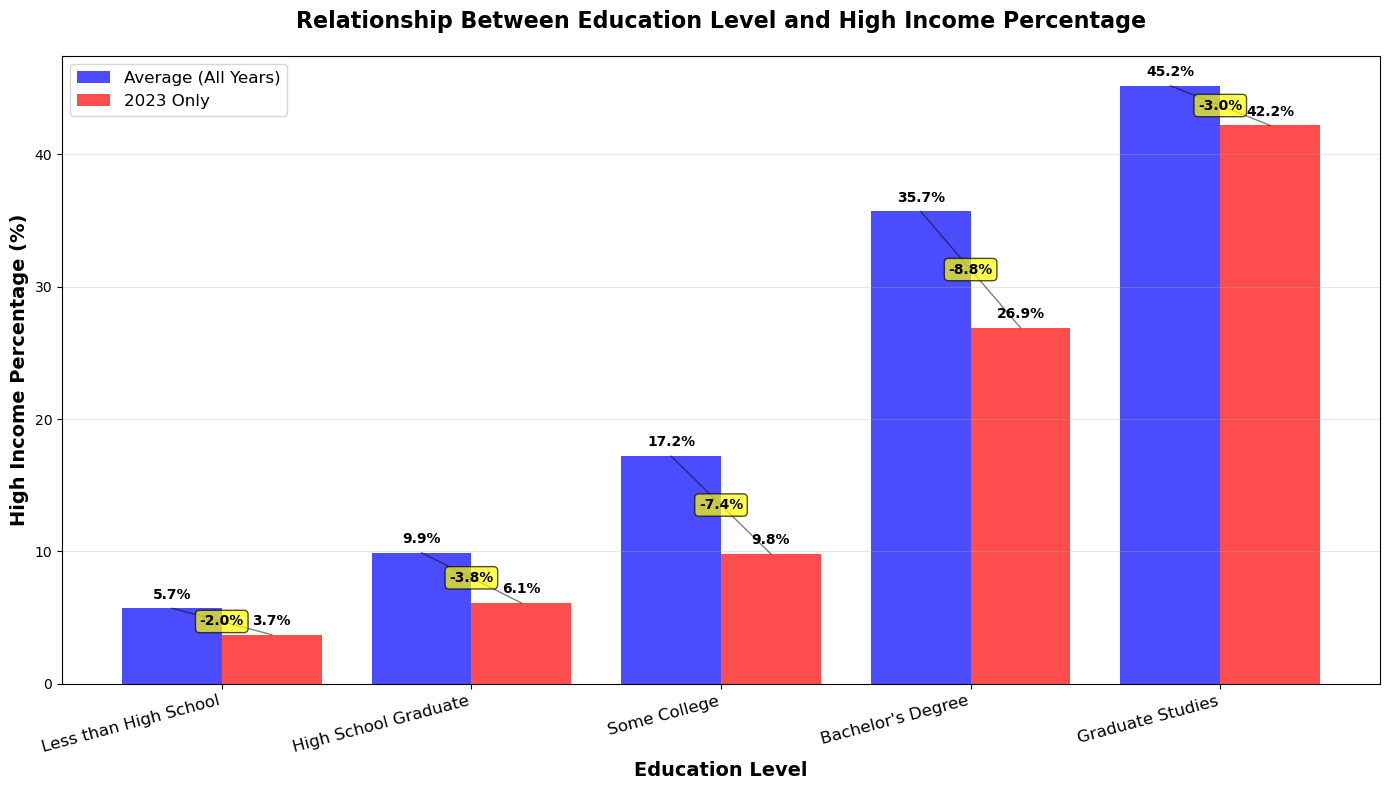

In [37]:
# Bar chart showing the relationship between education and income
education_levels = ['Less than High School', 'High School Graduate', 'Some College', 'Bachelor\'s Degree', 'Graduate Studies']
avg_percentages = [5.7, 9.9, 17.2, 35.7, 45.2]
latest_2023 = [3.7, 6.1, 9.8, 26.9, 42.2]

x_pos = np.arange(len(education_levels))

fig, ax = plt.subplots(figsize=(14, 8))

# Show average across all years
bars1 = ax.bar(x_pos - 0.2, avg_percentages, width=0.4,
               color='blue', alpha=0.7, label='Average (All Years)')

# Show 2023 only
bars2 = ax.bar(x_pos + 0.2, latest_2023, width=0.4,
               color='red', alpha=0.7, label='2023 Only')

# Improve appearance
ax.set_xlabel('Education Level', fontsize=14, fontweight='bold')
ax.set_ylabel('High Income Percentage (%)', fontsize=14, fontweight='bold')
ax.set_title('Relationship Between Education Level and High Income Percentage',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(education_levels, rotation=15, ha='right', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Add values on bars
def add_values(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

add_values(bars1)
add_values(bars2)

# Add connecting lines for change
for i in range(len(education_levels)):
    ax.plot([x_pos[i] - 0.2, x_pos[i] + 0.2],
            [avg_percentages[i], latest_2023[i]],
            'k-', linewidth=1, alpha=0.5)
    
    # Calculate difference
    diff = latest_2023[i] - avg_percentages[i]
    diff_text = f"{diff:+.1f}%" if diff >= 0 else f"{diff:.1f}%"
    ax.text(x_pos[i], (avg_percentages[i] + latest_2023[i]) / 2,
            diff_text, ha='center', va='center',
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.tight_layout()
plt.show()

In [38]:
def inspect_occupation_columns():
    print("\n Inspecting occupation columns across all years")
    print("=" * 70)
    
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year]
        
        print(f"\n Year {year}:")
        print(f"   Number of columns: {len(df.columns)}")
        
        # Search for all occupation-related columns
        occupation_cols = []
        for col in df.columns:
            col_lower = str(col).lower()
            if any(keyword in col_lower for keyword in ['occupation', 'job', 'work', 'emp', 'occcode']):
                occupation_cols.append(col)
        
        print(f"   Occupation columns ({len(occupation_cols)}): {occupation_cols}")
        
        # Show samples of data if occupation columns exist
        for col in occupation_cols[:2]:  # Only first two columns for brevity
            if col in df.columns:
                print(f"\n    Column '{col}':")
                print(f"      Type: {df[col].dtype}")
                print(f"      Unique values: {df[col].nunique()}")
                
                # Show first 5 unique values
                unique_vals = df[col].dropna().unique()[:5]
                print(f"      Sample values: {unique_vals}")
                
                # If textual, show distribution
                if pd.api.types.is_string_dtype(df[col]) or pd.api.types.is_object_dtype(df[col]):
                    value_counts = df[col].value_counts().head(3)
                    print(f"      Top 3 most frequent occupations:")
                    for val, count in value_counts.items():
                        pct = (count / len(df)) * 100
                        print(f"        '{val}': {count:,} ({pct:.1f}%)")

inspect_occupation_columns()


 Inspecting occupation columns across all years

 Year 1994:
   Number of columns: 28
   Occupation columns (6): ['workclass', 'occupation', 'occupation_sector_acs', 'workclass_simple', 'workclass_detailed', 'occupation_en']

    Column 'workclass':
      Type: object
      Unique values: 7
      Sample values: ['Private' 'State Government' 'Federal Government' 'Self-Employed (Sole)'
 'Local Government']
      Top 3 most frequent occupations:
        'Private': 15,267 (76.4%)
        'Local Government': 1,452 (7.3%)
        'Self-Employed (Sole)': 1,153 (5.8%)

    Column 'occupation':
      Type: object
      Unique values: 14
      Sample values: ['Machine-op-inspct' 'Prof-specialty' 'Adm-clerical' 'Other-service'
 'Handlers-cleaners']
      Top 3 most frequent occupations:
        'Adm-clerical': 3,035 (15.2%)
        'Craft-repair': 2,808 (14.1%)
        'Other-service': 2,546 (12.7%)

 Year 2000:
   Number of columns: 29
   Occupation columns (4): ['workclass', 'workclass_simple'

In [39]:
def apply_military_correction_to_current_data():
    """
    Apply military correction to current data
    """
    print("\n Applying military correction to current data")
    print("=" * 70)
    
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year]
        
        print(f"\n {year}:")
        
        other_counts = {}
        
# Check occupation_en
        if 'occupation_en' in df.columns:
            other_in_en = (df['occupation_en'] == 'Other').sum()
            if other_in_en > 0:
                other_counts['occupation_en'] = other_in_en
        
# Check occupation_unified (if exists)
        if 'occupation_unified' in df.columns:
            other_in_unified = (df['occupation_unified'] == 'Other').sum()
            if other_in_unified > 0:
                other_counts['occupation_unified'] = other_in_unified
        

        if other_counts:
            print(f"    Found 'Other' in columns: {other_counts}")
            
            # Correct occupation_en
            if 'occupation_en' in df.columns and 'occupation_en' in other_counts:
                military_before = other_counts['occupation_en']
                df['occupation_en'] = df['occupation_en'].replace('Other', 'Military')
                print(f"    occupation_en: 'Other' → 'Military' ({military_before:,} records)")
            
            # Correct occupation_unified
            if 'occupation_unified' in df.columns and 'occupation_unified' in other_counts:
                military_before = other_counts['occupation_unified']
                df['occupation_unified'] = df['occupation_unified'].replace('Other', 'Military')
                print(f"    occupation_unified: 'Other' → 'Military' ({military_before:,} records)")
            
            # Add detailed military category if OCCSOC exists
            if 'OCCSOC' in df.columns:
                def detailed_military(row):
                    if 'occupation_en' in row and row['occupation_en'] == 'Military':
                        occsoc = str(row['OCCSOC'])
                        if occsoc.startswith('551'):
                            return 'Military Officer'
                        elif occsoc.startswith('552'):
                            return 'Military NCO'
                        elif occsoc.startswith('553'):
                            return 'Military Enlisted'
                        elif occsoc.startswith('559'):
                            return 'Military Trainee'
                    return row.get('occupation_en', '')
                
                df['occupation_en_detailed'] = df.apply(detailed_military, axis=1)
                print(f"    Added occupation_en_detailed (Detailed military classification)")
        
        else:
            print(f"    No 'Other' found in occupation data")
        
        # Update general occupation group
        if 'occ_group' in df.columns:
            # Update occ_group to include military
            def update_occ_group(row):
                occupation = str(row.get('occupation_en', row.get('occupation_unified', '')))
                
                if 'Military' in occupation:
                    return 'Military'
                elif 'Management' in occupation or 'Manager' in occupation:
                    return 'Management'
                elif 'Computer' in occupation or 'IT' in occupation or 'Engineering' in occupation:
                    return 'Technology'
                elif 'Healthcare' in occupation or 'Medical' in occupation:
                    return 'Healthcare'
                elif 'Education' in occupation or 'Teacher' in occupation:
                    return 'Education'
                elif 'Office' in occupation or 'Business' in occupation:
                    return 'Business/Office'
                elif 'Sales' in occupation or 'Marketing' in occupation:
                    return 'Sales/Marketing'
                elif 'Construction' in occupation or 'Maintenance' in occupation:
                    return 'Construction'
                elif 'Food' in occupation or 'Service' in occupation:
                    return 'Food Service'
                elif 'Transportation' in occupation:
                    return 'Transportation'
                else:
                    return 'Other Services'
            
            df['occ_group'] = df.apply(update_occ_group, axis=1)
            print(f"    Updated occ_group to include 'Military'")
        
        # 5. Military statistics
        if 'occupation_en' in df.columns:
            military_count = (df['occupation_en'] == 'Military').sum()
            if military_count > 0:
                military_pct = (military_count / len(df)) * 100
                
                if 'income_high_unified' in df.columns:
                    military_high_pct = df[df['occupation_en'] == 'Military']['income_high_unified'].mean() * 100
                    overall_high_pct = df['income_high_unified'].mean() * 100
                    
                    print(f"    Military: {military_count:,} ({military_pct:.2f}%)")
                    print(f"    High income percentage:")
                    print(f"     Military: {military_high_pct:.1f}%")
                    print(f"     Overall: {overall_high_pct:.1f}%")
                    print(f"     Difference: {military_high_pct - overall_high_pct:+.1f} points")

apply_military_correction_to_current_data()


 Applying military correction to current data

 1994:
    Found 'Other' in columns: {'occupation_en': np.int64(5)}
    occupation_en: 'Other' → 'Military' (5 records)
    Added occupation_en_detailed (Detailed military classification)
    Military: 5 (0.03%)
    High income percentage:
     Military: 20.0%
     Overall: 18.8%
     Difference: +1.2 points

 2000:
    Found 'Other' in columns: {'occupation_en': np.int64(113)}
    occupation_en: 'Other' → 'Military' (113 records)
    Added occupation_en_detailed (Detailed military classification)
    Military: 113 (0.09%)
    High income percentage:
     Military: 9.7%
     Overall: 9.5%
     Difference: +0.3 points

 2010:
    Found 'Other' in columns: {'occupation_en': np.int64(10764)}
    occupation_en: 'Other' → 'Military' (10,764 records)
    Added occupation_en_detailed (Detailed military classification)
    Military: 10,764 (0.21%)
    High income percentage:
     Military: 10.8%
     Overall: 11.9%
     Difference: -1.1 points

 

In [40]:
def list_all_occupation_columns():
    print("\nAll occupation and work columns for each year")
    print("=" * 80)
    
    all_occupation_cols = set()
    occupation_columns_by_year = {}
    
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year]
        
        print(f"\nYear {year}:")
        print(f"   Total columns: {len(df.columns)}")
        
# Search for occupation and work columns
        occupation_cols = []
        for col in df.columns:
            col_lower = str(col).lower()
            # Keywords for occupation and work
            keywords = ['occupation', 'occ', 'work', 'emp', 'ind', 'profession']
            if any(keyword in col_lower for keyword in keywords):
                occupation_cols.append(col)
                all_occupation_cols.add(col)
        
        occupation_columns_by_year[year] = occupation_cols
        
        if occupation_cols:
            print(f"   Occupation/Work columns ({len(occupation_cols)}):")
            for col in sorted(occupation_cols):
                # Display information about the column
                print(f"      '{col}':")
                
                if col in df.columns:
                    # Data type
                    print(f"         Type: {df[col].dtype}")
                    
                    # If textual, display samples
                    if pd.api.types.is_string_dtype(df[col]) or pd.api.types.is_object_dtype(df[col]):
                        unique_count = df[col].nunique()
                        print(f"         Unique values: {unique_count:,}")
                        
                        if unique_count <= 10:
                            unique_vals = df[col].dropna().unique()[:5]
                            print(f"         Samples: {unique_vals}")
                        elif unique_count <= 50:
                            # Display some common values
                            top_vals = df[col].value_counts().head(3)
                            print(f"         Top 3 frequent values:")
                            for val, count in top_vals.items():
                                print(f"           '{val}': {count:,}")
        
        else:
            print(f"   No occupation/work columns found")
    
    # Comparative analysis
    print(f"\n" + "=" * 80)
    print("Comparative Analysis:")
    print("=" * 80)
    
    print(f"\nAll unique occupation columns across years ({len(all_occupation_cols)}):")
    for col in sorted(all_occupation_cols):
        years_with_col = [year for year, cols in occupation_columns_by_year.items() if col in cols]
        print(f"   '{col}': present in years {years_with_col}")
    
    # Find columns common in at least 3 years
    print(f"\nColumns common in at least 3 years:")
    common_cols = []
    for col in all_occupation_cols:
        years_count = sum(1 for year, cols in occupation_columns_by_year.items() if col in cols)
        if years_count >= 3:
            common_cols.append((col, years_count))
    
    common_cols.sort(key=lambda x: x[1], reverse=True)
    
    for col, count in common_cols:
        years = [year for year, cols in occupation_columns_by_year.items() if col in cols]
        print(f"   '{col}': {count} years → {sorted(years)}")
    
    return occupation_columns_by_year, all_occupation_cols

occupation_cols_by_year, all_occ_cols = list_all_occupation_columns()


All occupation and work columns for each year

Year 1994:
   Total columns: 29
   Occupation/Work columns (8):
      'OCCSOC':
         Type: int64
      'occupation':
         Type: object
         Unique values: 14
         Top 3 frequent values:
           'Adm-clerical': 3,035
           'Craft-repair': 2,808
           'Other-service': 2,546
      'occupation_en':
         Type: object
         Unique values: 14
         Top 3 frequent values:
           'Office Support': 3,035
           'Maintenance': 2,808
           'Building Maintenance': 2,546
      'occupation_en_detailed':
         Type: object
         Unique values: 14
         Top 3 frequent values:
           'Office Support': 3,035
           'Maintenance': 2,808
           'Building Maintenance': 2,546
      'occupation_sector_acs':
         Type: object
         Unique values: 14
         Top 3 frequent values:
           'Office and administrative support occupations': 3,035
           'Installation, maintenance, 

In [41]:
def show_common_and_uncommon_columns():
    print("Common and Uncommon Columns")
    print("=" * 60)
# Collect columns for each year
    all_columns_sets = []
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year]
        columns = set(df.columns)
        all_columns_sets.append(columns)
        print(f"{year}: {len(columns)} columns")
    
# Find common columns
    common_columns = set.intersection(*all_columns_sets)
    
    print(f"\nCommon columns across all years ({len(common_columns)}):")
    for col in sorted(common_columns):
        print(f"  {col}")
    
# Find uncommon columns for each year
    print(f"\nUncommon columns (not deleted, just shown):")
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year]
        current_columns = set(df.columns)
        uncommon_columns = current_columns - common_columns
        
        if uncommon_columns:
            print(f"\nYear {year}:")
            print(f"   Number of uncommon columns: {len(uncommon_columns)}")
            
            # Show only first 10 uncommon columns
            sample_cols = list(uncommon_columns)[:10]
            for col in sample_cols:
                print(f"   {col}")
            
            if len(uncommon_columns) > 10:
                print(f"   ... and {len(uncommon_columns) - 10} more columns")
        else:
            print(f"\nYear {year}: No uncommon columns")
    
    return common_columns

common_cols_preview = show_common_and_uncommon_columns()

Common and Uncommon Columns
1994: 28 columns
2000: 30 columns
2010: 30 columns
2019: 38 columns
2021: 38 columns
2023: 38 columns

Common columns across all years (22):
  INCTOT
  OCCSOC
  YEAR
  age
  age_group
  age_group_acs
  age_group_label
  education
  education_level_acs
  education_years
  gender
  hours_group
  hours_per_week
  income_high_unified
  income_main
  marital_group
  marital_status
  occupation_en
  occupation_en_detailed
  workclass
  workclass_detailed
  workclass_simple

Uncommon columns (not deleted, just shown):

Year 1994:
   Number of uncommon columns: 6
   occupation_sector_acs
   income_2023_adjusted
   income_2023_value
   capital_loss
   capital_gain
   occupation

Year 2000:
   Number of uncommon columns: 8
   MARST
   CLASSWKRD
   education_detailed_code
   IND
   CLASSWKR
   EDUC
   EDUCD
   OCC

Year 2010:
   Number of uncommon columns: 8
   MARST
   CLASSWKRD
   education_detailed_code
   IND
   CLASSWKR
   EDUC
   EDUCD
   OCC

Year 2019:
   Numbe

In [42]:
def remove_uncommon_columns(common_columns):
    deleted_counts = {}
    
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year]
        current_columns = set(df.columns)
        uncommon_columns = current_columns - common_columns
        
        if uncommon_columns:
            cols_to_delete = list(uncommon_columns)
            df.drop(columns=cols_to_delete, inplace=True, errors='ignore')
            deleted_counts[year] = len(uncommon_columns)
        else:
            deleted_counts[year] = 0
    
    print("\nFinal result after removal:")
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year]
        print(f"{year}: {len(df.columns)} columns (removed {deleted_counts[year]})")
    
    return deleted_counts

In [43]:
def verify_columns_after_removal():

    print("\nVerification after removal")
    print("=" * 60)
    
    # Collect the final columns for each year
    final_columns_sets = [set(df.columns) for df in six_years_data.values()]
    
    # Check if all years have the same columns
    all_same = all(cols == final_columns_sets[0] for cols in final_columns_sets)
    
    if all_same:
        print(f"All years now have the same columns ({len(final_columns_sets[0])} columns).")
        print("Columns list:")
        for col in sorted(final_columns_sets[0]):
            print(f"  {col}")
    else:
        print("Columns are still different between years.")
        for i, year in enumerate(sorted(six_years_data.keys())):
            print(f"{year}: {len(final_columns_sets[i])} columns")

verify_columns_after_removal()


Verification after removal
Columns are still different between years.
1994: 28 columns
2000: 30 columns
2010: 30 columns
2019: 38 columns
2021: 38 columns
2023: 38 columns


In [44]:
def show_columns_by_year():
    print("\nColumns by Year")
    print("=" * 60)
    
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year]
        print(f"\nYear {year}: {len(df.columns)} columns")
        print("-" * 40)
        for col in sorted(df.columns):
            print(f"  {col}")

show_columns_by_year()


Columns by Year

Year 1994: 29 columns
----------------------------------------
  INCTOT
  INCTOT
  OCCSOC
  YEAR
  age
  age_group
  age_group_acs
  age_group_label
  capital_gain
  capital_loss
  education
  education_level_acs
  education_years
  gender
  hours_group
  hours_per_week
  income_2023_adjusted
  income_2023_value
  income_high_unified
  income_main
  marital_group
  marital_status
  occupation
  occupation_en
  occupation_en_detailed
  occupation_sector_acs
  workclass
  workclass_detailed
  workclass_simple

Year 2000: 30 columns
----------------------------------------
  CLASSWKR
  CLASSWKRD
  EDUC
  EDUCD
  INCTOT
  IND
  MARST
  OCC
  OCCSOC
  YEAR
  age
  age_group
  age_group_acs
  age_group_label
  education
  education_detailed_code
  education_level_acs
  education_years
  gender
  hours_group
  hours_per_week
  income_high_unified
  income_main
  marital_group
  marital_status
  occupation_en
  occupation_en_detailed
  workclass
  workclass_detailed
  workcla

In [45]:
def force_keep_only_common_columns():
    # Collect sets of columns
    all_columns_sets = [set(df.columns) for df in six_years_data.values()]
    
    # Find intersection (columns present in all years)
    common_columns = set.intersection(*all_columns_sets)
    
    print(f"Final common columns ({len(common_columns)}):")
    for col in sorted(common_columns):
        print(f"  {col}")
    
    # Force each DataFrame to keep only these columns
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year]
        df.drop(columns=[c for c in df.columns if c not in common_columns],
                inplace=True, errors='ignore')
        print(f"Year {year}: now {len(df.columns)} columns")
    
    return common_columns

# Run the strict removal
final_common_cols = force_keep_only_common_columns()

Final common columns (22):
  INCTOT
  OCCSOC
  YEAR
  age
  age_group
  age_group_acs
  age_group_label
  education
  education_level_acs
  education_years
  gender
  hours_group
  hours_per_week
  income_high_unified
  income_main
  marital_group
  marital_status
  occupation_en
  occupation_en_detailed
  workclass
  workclass_detailed
  workclass_simple
Year 1994: now 23 columns
Year 2000: now 22 columns
Year 2010: now 22 columns
Year 2019: now 22 columns
Year 2021: now 22 columns
Year 2023: now 22 columns


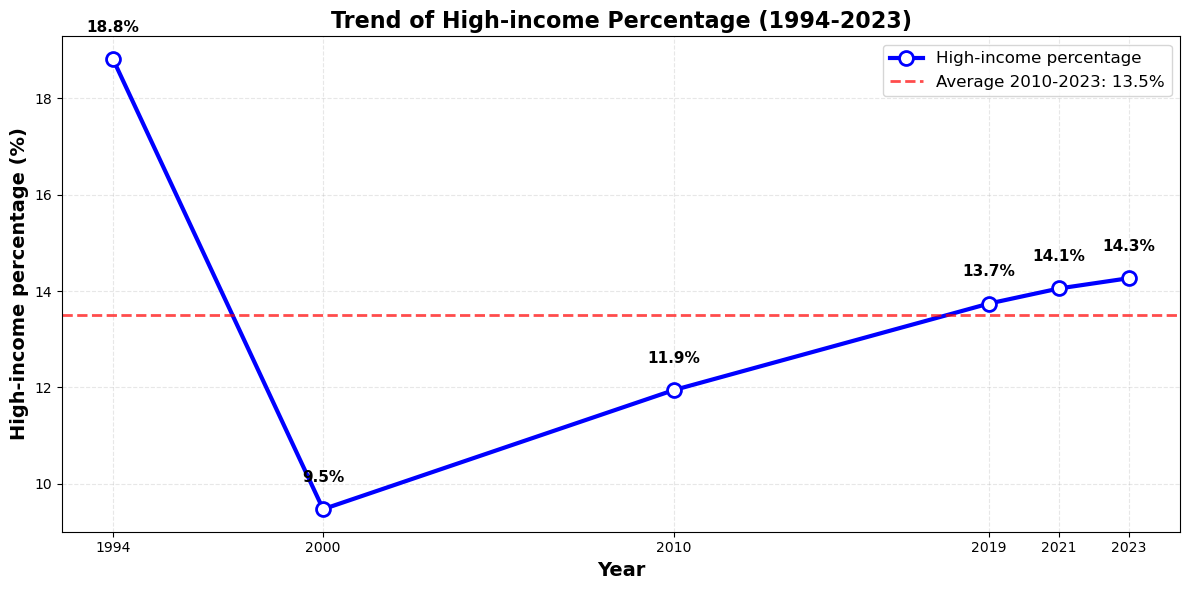

In [46]:
def plot_high_income_trend():
    """
    Plot the trend of high-income percentage across years
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Collect data
    years = []
    high_income_pct = []
    
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year]
        if 'income_high_unified' in df.columns:
            pct = df['income_high_unified'].mean() * 100
            years.append(year)
            high_income_pct.append(pct)
    
    # Plot
    plt.figure(figsize=(12, 6))
    
    # Main line
    plt.plot(years, high_income_pct, 'bo-', linewidth=3, markersize=10,
             markerfacecolor='white', markeredgewidth=2, label='High-income percentage')
    
    # Average line (2010-2023)
    if len(high_income_pct) >= 4:
        avg_recent = np.mean(high_income_pct[2:])  # from 2010
        plt.axhline(y=avg_recent, color='red', linestyle='--', linewidth=2,
                   label=f'Average 2010-2023: {avg_recent:.1f}%', alpha=0.7)
    
    # Formatting
    plt.xlabel('Year', fontsize=14, fontweight='bold')
    plt.ylabel('High-income percentage (%)', fontsize=14, fontweight='bold')
    plt.title('Trend of High-income Percentage (1994-2023)', fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xticks(years)
    
    # Add values on points
    for i, (year, pct) in enumerate(zip(years, high_income_pct)):
        plt.text(year, pct + 0.5, f'{pct:.1f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Plot the trend
plot_high_income_trend()

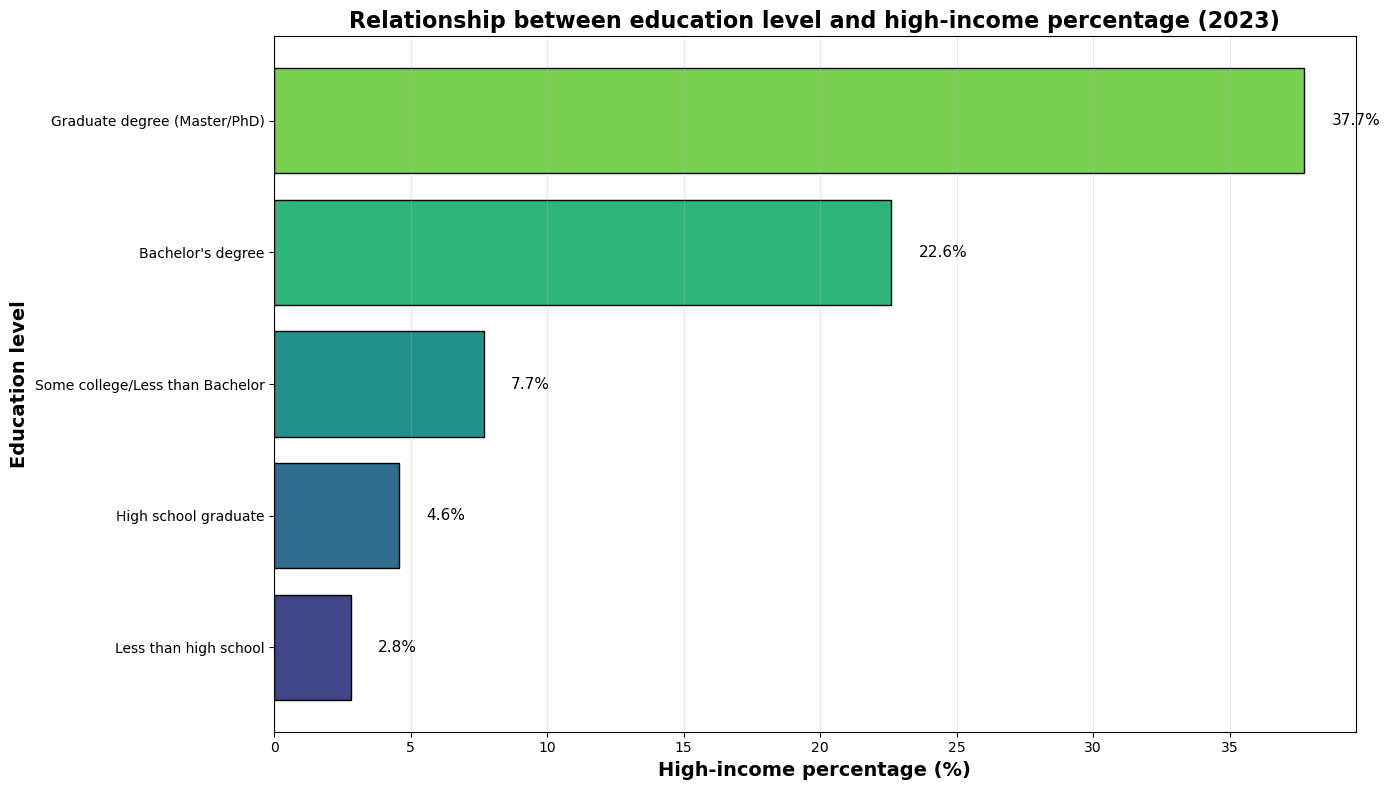


Relationship between education and income in 2023:
--------------------------------------------------
Graduate degree (Master/PhD): 37.7%
Bachelor's degree: 22.6%
Some college/Less than Bachelor: 7.7%
High school graduate: 4.6%
Less than high school: 2.8%


In [47]:
def plot_education_income_relation():
    """
    Plot the relationship between education and income
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Use 2023 as an example (latest year)
    year = 2023
    if year in six_years_data:
        df = six_years_data[year]
        
        if all(col in df.columns for col in ['education_level_acs', 'income_high_unified']):
            # Calculate percentages
            education_stats = []
            for edu_level in df['education_level_acs'].dropna().unique():
                subset = df[df['education_level_acs'] == edu_level]
                if len(subset) > 100:  # sufficient sample
                    high_pct = subset['income_high_unified'].mean() * 100
                    education_stats.append({
                        'education': edu_level,
                        'high_pct': high_pct,
                        'count': len(subset)
                    })
            
            # Sort by percentage
            education_stats.sort(key=lambda x: x['high_pct'])
            
            # Plot
            plt.figure(figsize=(14, 8))
            
            edu_levels = [stat['education'] for stat in education_stats]
            percentages = [stat['high_pct'] for stat in education_stats]
            
            colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(edu_levels)))
            bars = plt.barh(edu_levels, percentages, color=colors, edgecolor='black')
            
            # Formatting
            plt.xlabel('High-income percentage (%)', fontsize=14, fontweight='bold')
            plt.ylabel('Education level', fontsize=14, fontweight='bold')
            plt.title(f'Relationship between education level and high-income percentage ({year})',
                     fontsize=16, fontweight='bold')
            
            # Add values on bars
            for bar, pct in zip(bars, percentages):
                width = bar.get_width()
                plt.text(width + 1, bar.get_y() + bar.get_height()/2,
                        f'{pct:.1f}%', ha='left', va='center', fontsize=11)
            
            plt.grid(True, alpha=0.3, axis='x')
            plt.tight_layout()
            plt.show()
            
            # Print statistics
            print(f"\nRelationship between education and income in {year}:")
            print("-" * 50)
            for stat in sorted(education_stats, key=lambda x: x['high_pct'], reverse=True):
                print(f"{stat['education']}: {stat['high_pct']:.1f}%")

# Plot the relationship
plot_education_income_relation()

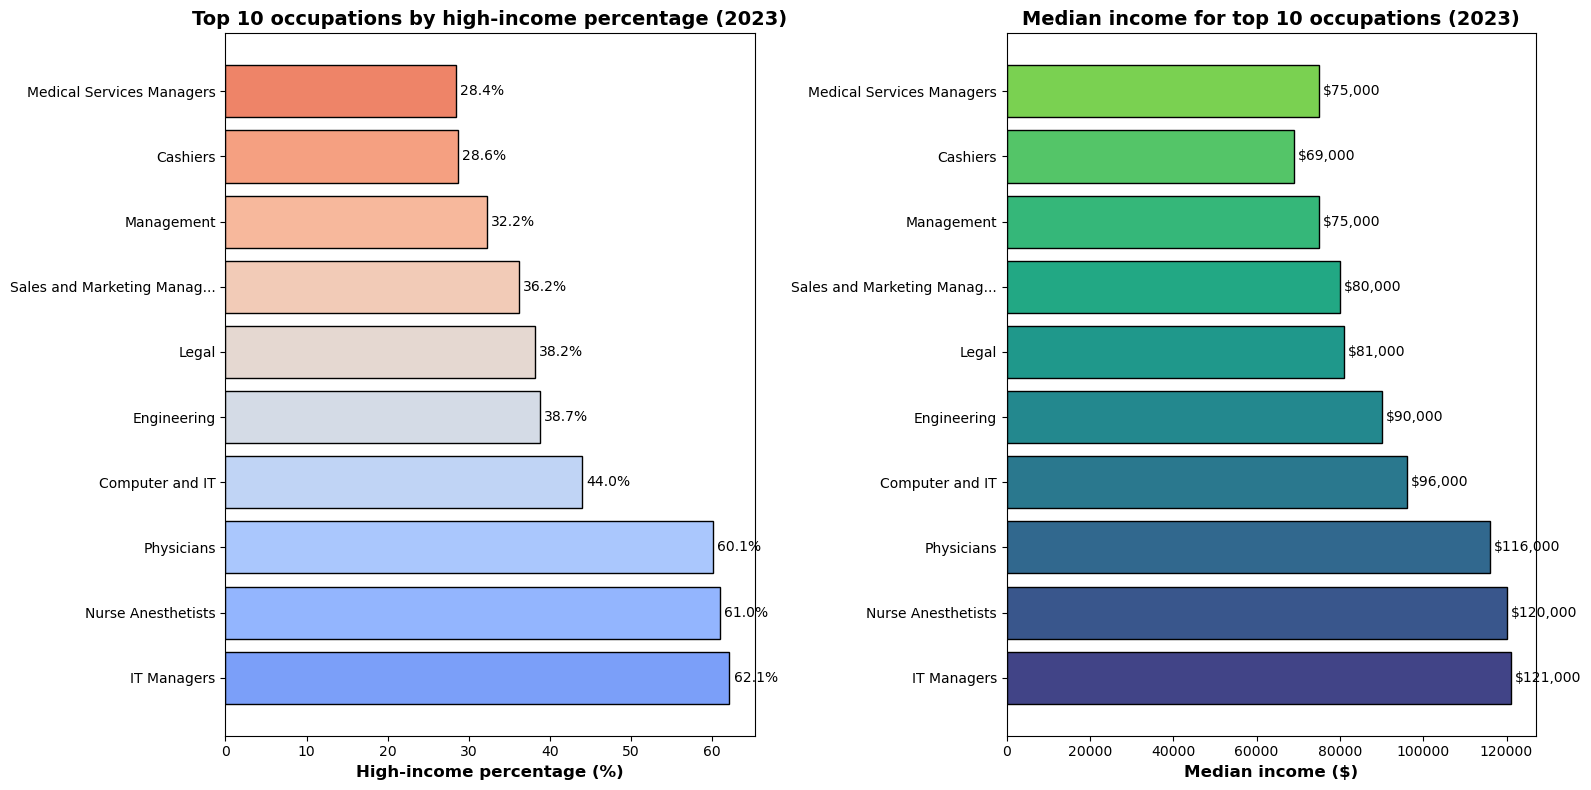


Top 10 occupations in 2023:
--------------------------------------------------------------------------------
Rank     Occupation                               High-income percentage Median income  
--------------------------------------------------------------------------------
1        IT Managers                              62.1               % $121,000       
2        Nurse Anesthetists                       61.0               % $120,000       
3        Physicians                               60.1               % $116,000       
4        Computer and IT                          44.0               % $96,000        
5        Engineering                              38.7               % $90,000        
6        Legal                                    38.2               % $81,000        
7        Sales and Marketing Managers             36.2               % $80,000        
8        Management                               32.2               % $75,000        
9        Cashiers       

In [48]:
def plot_top_occupations():
    """
    Plot the top 10 occupations by high-income percentage
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Use 2023 as an example
    year = 2023
    if year in six_years_data:
        df = six_years_data[year]
        
        if all(col in df.columns for col in ['occupation_en', 'income_high_unified']):
            # Calculate occupation statistics
            occupation_stats = []
            for occupation in df['occupation_en'].dropna().unique():
                subset = df[df['occupation_en'] == occupation]
                if len(subset) >= 100:  # sufficient sample
                    high_pct = subset['income_high_unified'].mean() * 100
                    median_income = subset['INCTOT'].median() if 'INCTOT' in subset.columns else 0
                    
                    occupation_stats.append({
                        'occupation': occupation,
                        'high_pct': high_pct,
                        'median_income': median_income,
                        'count': len(subset)
                    })
            
            # Sort and select top 10
            occupation_stats.sort(key=lambda x: x['high_pct'], reverse=True)
            top_10 = occupation_stats[:10]
            
            # Plot
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
            
            # Plot 1: High-income percentage
            occupations = [stat['occupation'][:25] + ("..." if len(stat['occupation']) > 25 else "")
                          for stat in top_10]
            percentages = [stat['high_pct'] for stat in top_10]
            
            colors1 = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(occupations)))
            bars1 = ax1.barh(occupations, percentages, color=colors1, edgecolor='black')
            
            ax1.set_xlabel('High-income percentage (%)', fontsize=12, fontweight='bold')
            ax1.set_title(f'Top 10 occupations by high-income percentage ({year})',
                         fontsize=14, fontweight='bold')
            
            for bar, pct in zip(bars1, percentages):
                width = bar.get_width()
                ax1.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                        f'{pct:.1f}%', ha='left', va='center', fontsize=10)
            
            # Plot 2: Median income
            median_incomes = [stat['median_income'] for stat in top_10]
            colors2 = plt.cm.viridis(np.linspace(0.2, 0.8, len(occupations)))
            bars2 = ax2.barh(occupations, median_incomes, color=colors2, edgecolor='black')
            
            ax2.set_xlabel('Median income ($)', fontsize=12, fontweight='bold')
            ax2.set_title(f'Median income for top 10 occupations ({year})',
                         fontsize=14, fontweight='bold')
            
            for bar, income in zip(bars2, median_incomes):
                width = bar.get_width()
                ax2.text(width + 1000, bar.get_y() + bar.get_height()/2,
                        f'${income:,.0f}', ha='left', va='center', fontsize=10)
            
            plt.tight_layout()
            plt.show()
            
            # Print table
            print(f"\nTop 10 occupations in {year}:")
            print("-" * 80)
            print(f"{'Rank':<8} {'Occupation':<40} {'High-income percentage':<20} {'Median income':<15}")
            print("-" * 80)
            for i, stat in enumerate(top_10, 1):
                occupation_display = stat['occupation']
                if len(occupation_display) > 37:
                    occupation_display = occupation_display[:34] + "..."
                print(f"{i:<8} {occupation_display:<40} {stat['high_pct']:<19.1f}% ${stat['median_income']:<14,.0f}")

# Plot top occupations
plot_top_occupations()

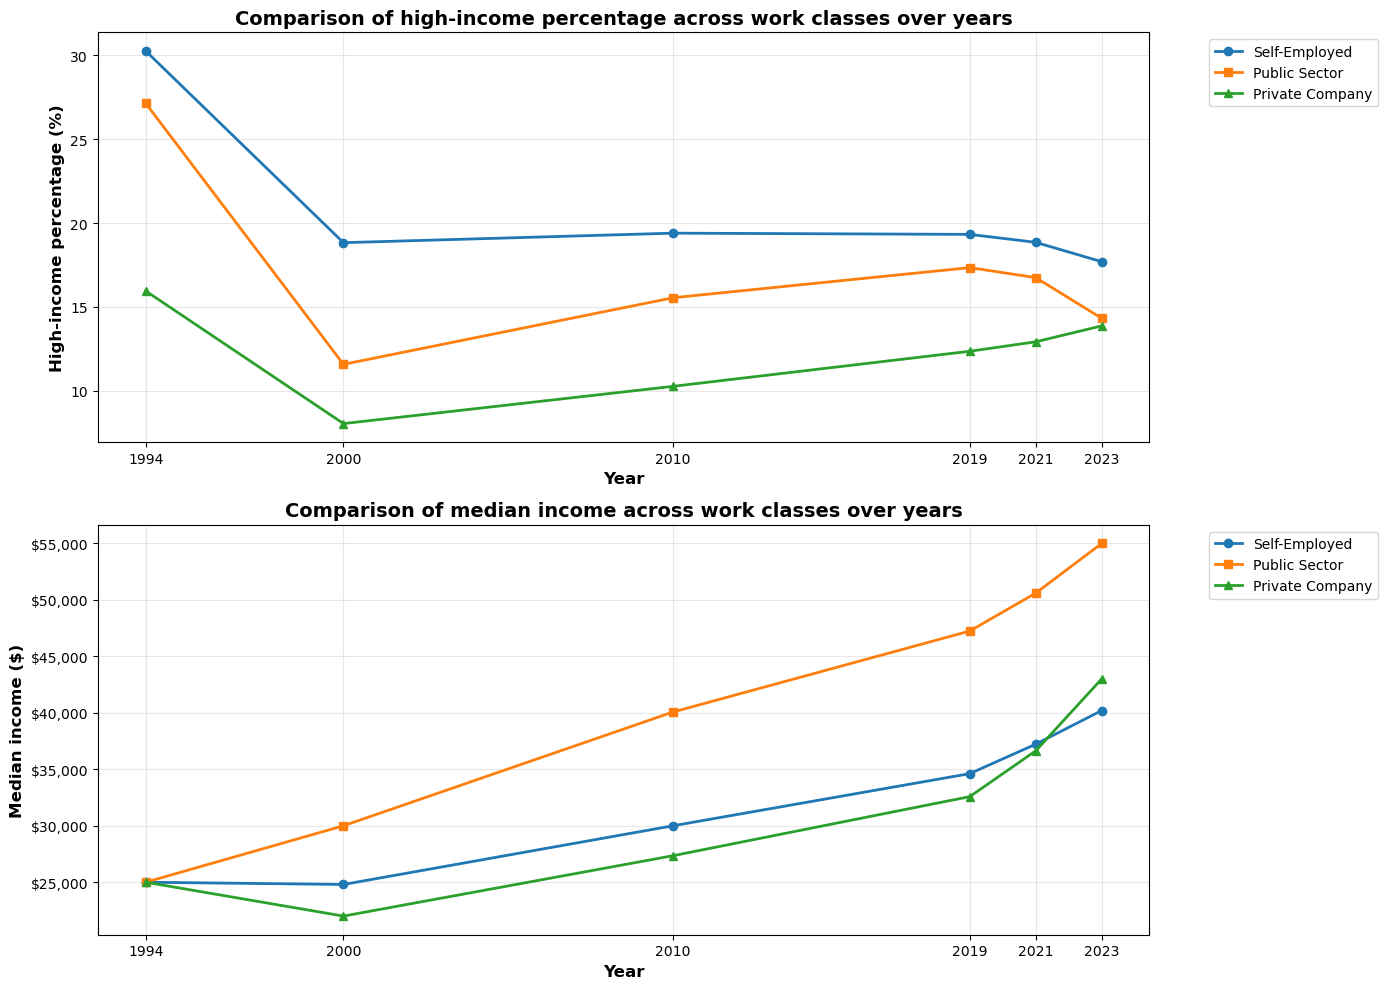

In [50]:
import matplotlib.pyplot as plt
import numpy as np

def plot_workclass_comparison_all_years():
    # Collect data from all years
    all_years_data = []
    
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year].copy()
        df = df.loc[:, ~df.columns.duplicated()]  # إزالة الأعمدة المكررة
        
        if all(col in df.columns for col in ['workclass_simple', 'income_high_unified', 'INCTOT']):
            year_stats = {'year': year, 'workclasses': {}}
            
            for workclass in df['workclass_simple'].dropna().unique():
                if workclass == "Non-Paid Work":
                    continue
                
                subset = df[df['workclass_simple'] == workclass]
                if len(subset) > 100:
                    high_pct = float(subset['income_high_unified'].mean() * 100)
                    median_income = float(subset['INCTOT'].median())
                    
                    year_stats['workclasses'][workclass] = {
                        'high_pct': high_pct,
                        'median_income': median_income,
                        'count': len(subset)
                    }
            
            all_years_data.append(year_stats)
    
    if not all_years_data:
        print("No sufficient data available")
        return
    
    # Collect all unique work classes
    all_workclasses = set()
    for year_data in all_years_data:
        all_workclasses.update(year_data['workclasses'].keys())
    
    years = sorted([data['year'] for data in all_years_data])
    
    workclass_percentages = {}
    workclass_incomes = {}
    
    for workclass in all_workclasses:
        percentages = []
        incomes = []
        
        for year in years:
            found = False
            for year_data in all_years_data:
                if year_data['year'] == year and workclass in year_data['workclasses']:
                    percentages.append(float(year_data['workclasses'][workclass]['high_pct']))
                    incomes.append(float(year_data['workclasses'][workclass]['median_income']))
                    found = True
                    break
            
            if not found:
                percentages.append(np.nan)
                incomes.append(np.nan)
        
        workclass_percentages[workclass] = percentages
        workclass_incomes[workclass] = incomes
    
    # Plot 2-1: High-income percentage across years
    fig2, (ax2_1, ax2_2) = plt.subplots(2, 1, figsize=(14, 10))
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
    
    for idx, (workclass, percentages) in enumerate(workclass_percentages.items()):
        valid_indices = [i for i, pct in enumerate(percentages) if not np.isnan(pct)]
        valid_years = [years[i] for i in valid_indices]
        valid_percentages = [percentages[i] for i in valid_indices]
        
        if valid_percentages:
            ax2_1.plot(valid_years, valid_percentages,
                      marker=markers[idx % len(markers)],
                      linewidth=2,
                      markersize=6,
                      label=workclass)
    
    ax2_1.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax2_1.set_ylabel('High-income percentage (%)', fontsize=12, fontweight='bold')
    ax2_1.set_title('Comparison of high-income percentage across work classes over years',
                   fontsize=14, fontweight='bold')
    ax2_1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2_1.grid(True, alpha=0.3)
    ax2_1.set_xticks(years)
    
    # Plot 2-2: Median income across years
    for idx, (workclass, incomes) in enumerate(workclass_incomes.items()):
        valid_indices = [i for i, inc in enumerate(incomes) if not np.isnan(inc)]
        valid_years = [years[i] for i in valid_indices]
        valid_incomes = [incomes[i] for i in valid_indices]
        
        if valid_incomes:
            ax2_2.plot(valid_years, valid_incomes,
                      marker=markers[idx % len(markers)],
                      linewidth=2,
                      markersize=6,
                      label=workclass)
    
    ax2_2.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax2_2.set_ylabel('Median income ($)', fontsize=12, fontweight='bold')
    ax2_2.set_title('Comparison of median income across work classes over years',
                   fontsize=14, fontweight='bold')
    ax2_2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2_2.grid(True, alpha=0.3)
    ax2_2.set_xticks(years)
    ax2_2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    
    plt.tight_layout()
    plt.show()

plot_workclass_comparison_all_years()

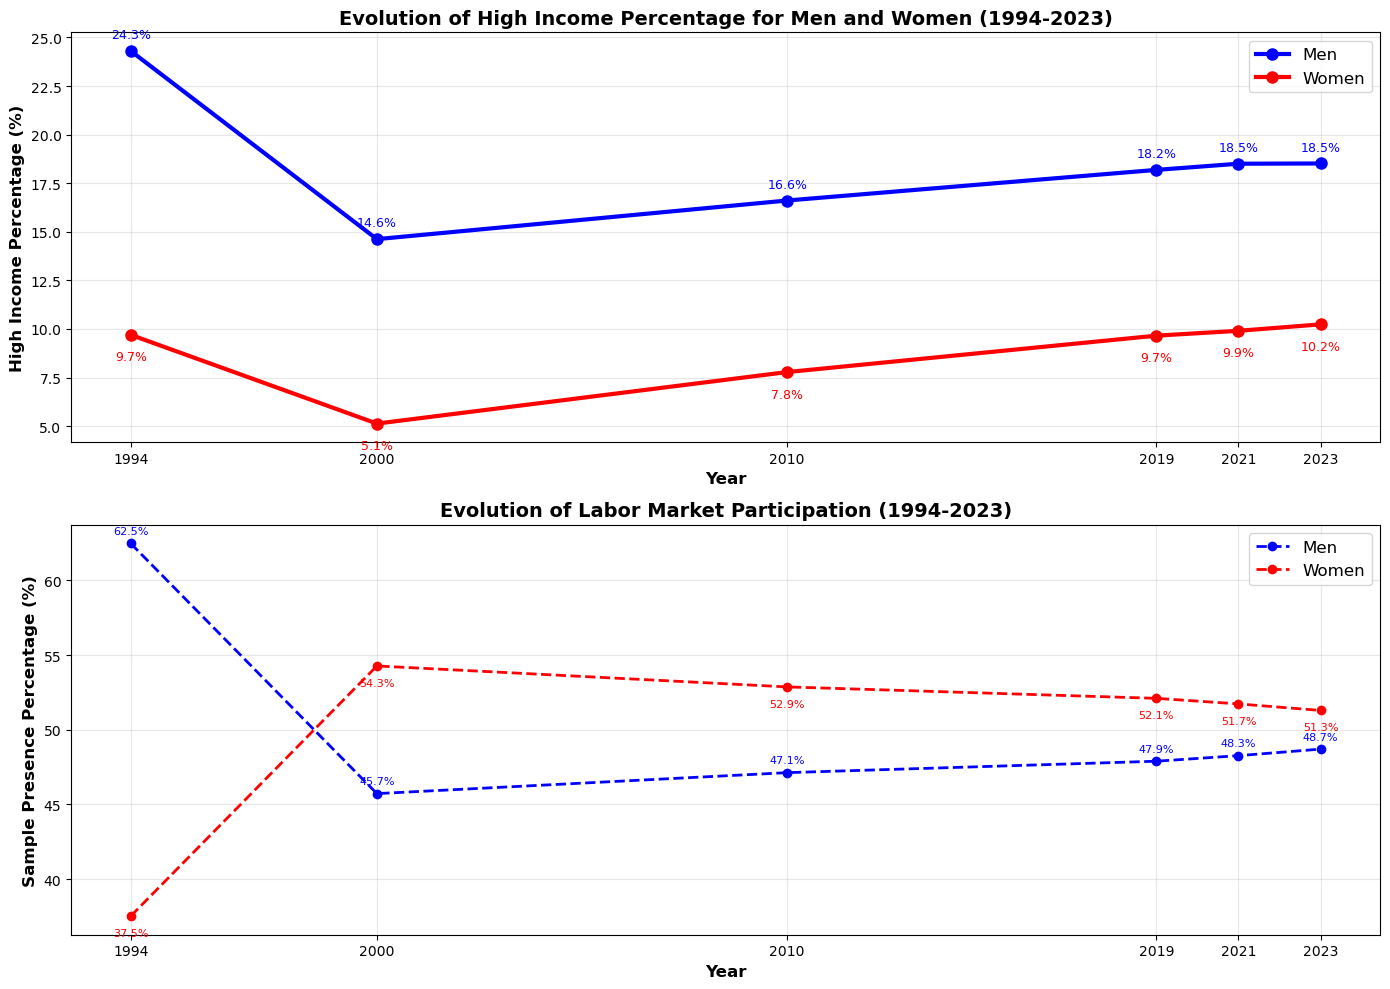

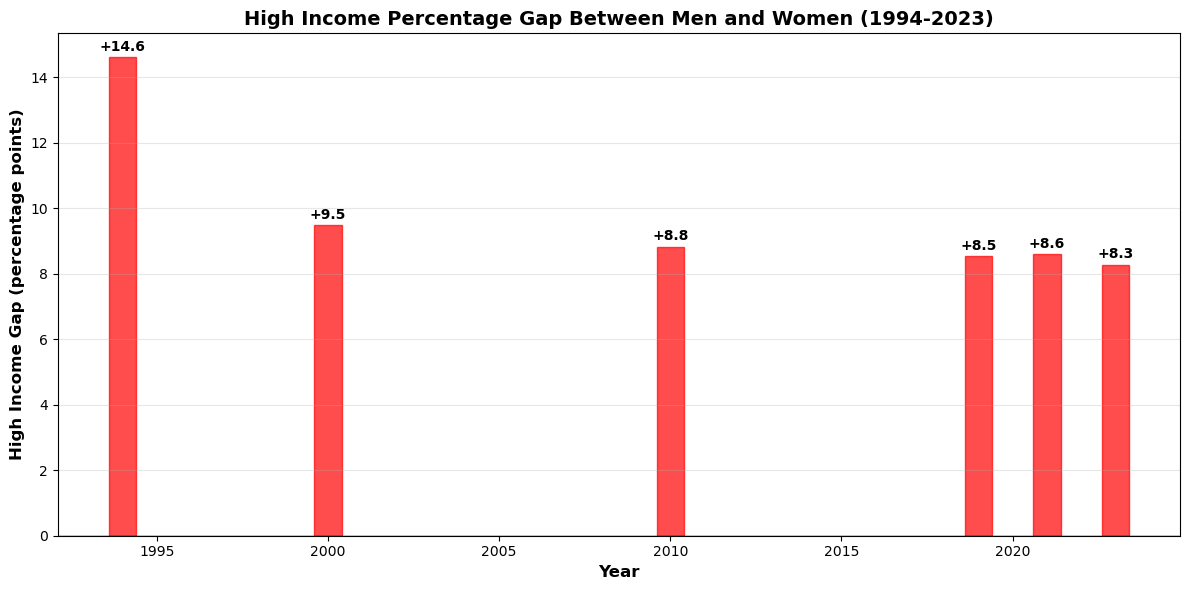

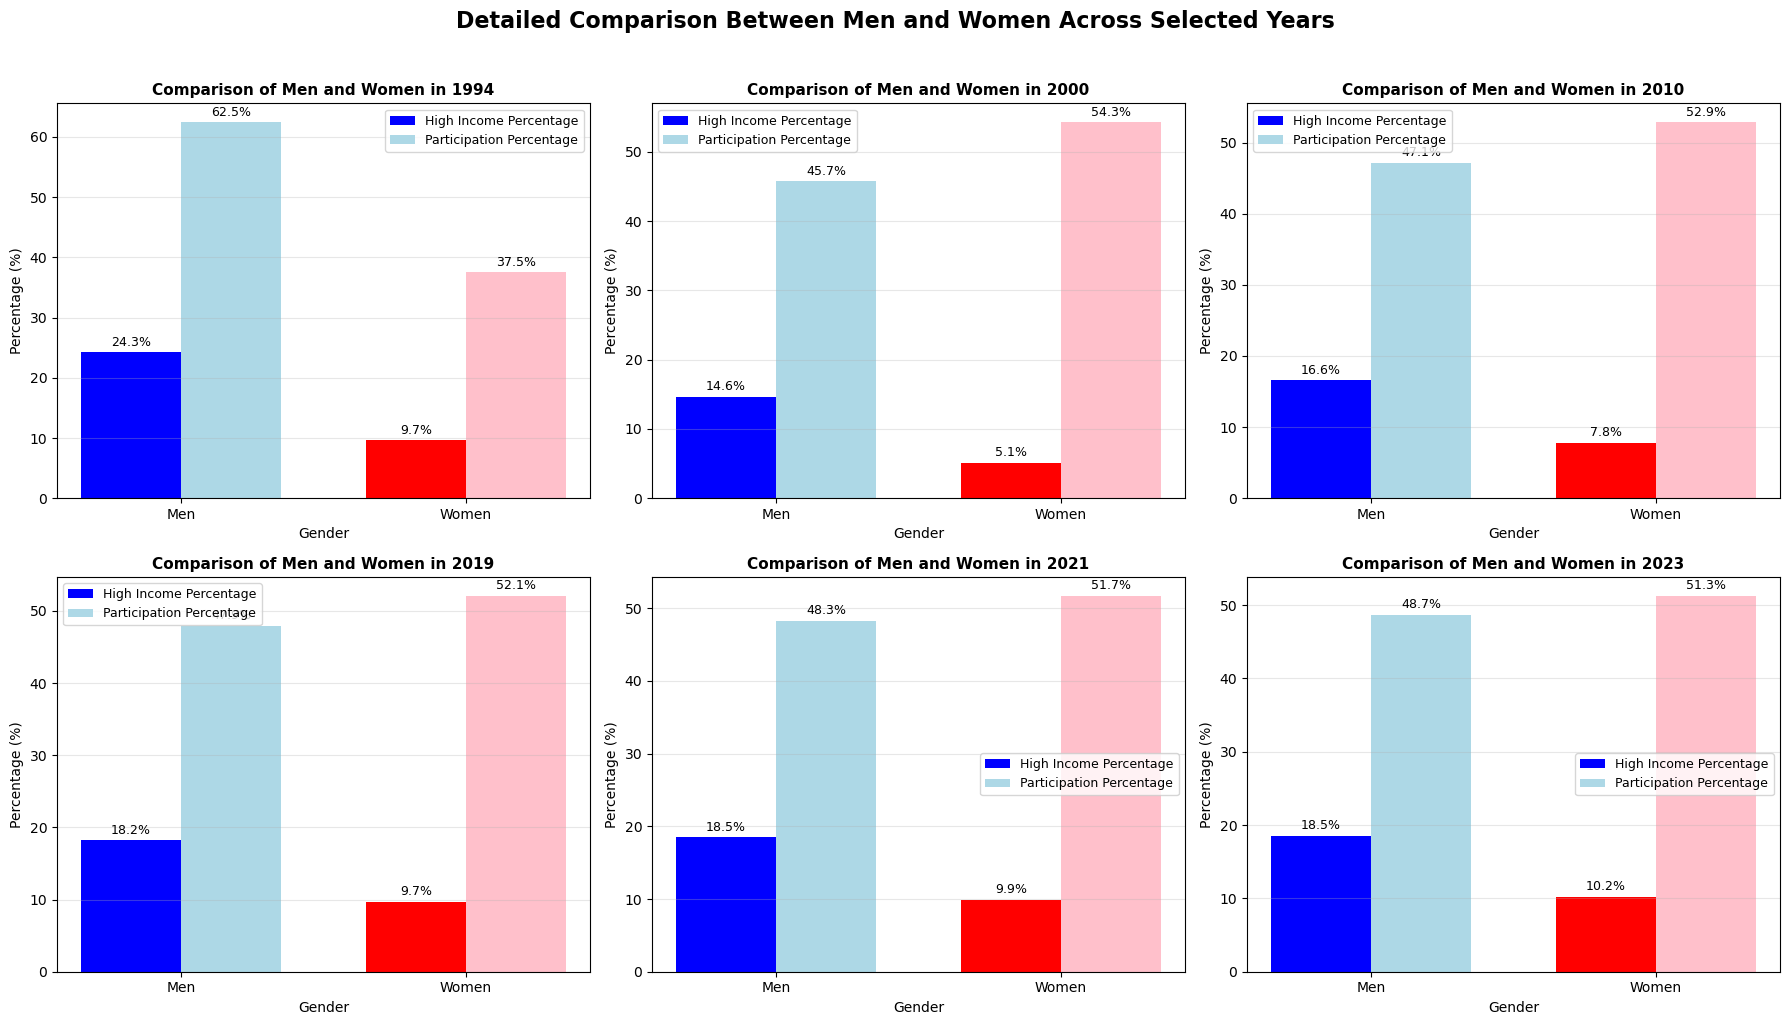


Detailed Comparison Table of Men and Women Across Years:

Year 1994:
------------------------------------------------------------------------------------------------------------------------
Indicator                 Men             Women           Difference (Men - Women) Gap Percentage 
------------------------------------------------------------------------------------------------------------------------
High Income Percentage    24.3          % 9.7           % 14.6                points 60.1          %
Participation Percentage  62.5          % 37.5          % 24.9                points 39.9          %
Median Income             $25,000        $25,000        $0                  0.0          %
Number of People          12,476         7,496         

Year 2000:
------------------------------------------------------------------------------------------------------------------------
Indicator                 Men             Women           Difference (Men - Women) Gap Percentage 
--------

In [55]:
def plot_gender_comparison_all_years():
    """
    Compare between men and women across all years (1994-2023)
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    # Collect data from all years
    gender_data_by_year = []

    for year in sorted(six_years_data.keys()):
        df = six_years_data[year]

        if all(col in df.columns for col in ['gender', 'income_high_unified']):
            year_stats = {'year': year, 'gender_stats': {}}

            for gender in df['gender'].dropna().unique():
                subset = df[df['gender'] == gender]
                if len(subset) > 0:
                    # 1. High income percentage
                    high_pct = subset['income_high_unified'].mean() * 100

                    # 2. Labor market participation percentage (if working)
                    total_people = len(df)
                    gender_count = len(subset)
                    labor_participation = (gender_count / total_people) * 100

                    # 3. Average income if available - FIXED PROPERLY
                    median_income = 0
                    if 'INCTOT' in subset.columns:
                        try:
                            # Use .median() and ensure it's a scalar
                            median_val = subset['INCTOT'].median()
                            
                            # Check if median_val is a Series or scalar
                            if isinstance(median_val, pd.Series):
                                if not median_val.empty:
                                    median_income = float(median_val.iloc[0])
                            else:
                                # Check if it's NaN using numpy
                                if not np.isnan(median_val):
                                    median_income = float(median_val)
                        except:
                            median_income = 0

                    year_stats['gender_stats'][gender] = {
                        'high_pct': high_pct,
                        'labor_participation': labor_participation,
                        'median_income': median_income,  # Now a scalar value
                        'count': gender_count
                    }

            gender_data_by_year.append(year_stats)

    if not gender_data_by_year:
        print("Insufficient data")
        return

    # 1. Chart 1: Evolution of high income percentage for men and women across years
    fig1, (ax1_1, ax1_2) = plt.subplots(2, 1, figsize=(14, 10))

    # Prepare data
    years = sorted([data['year'] for data in gender_data_by_year])

    # For each gender, create a list of percentages across years
    gender_high_pct = {'Male': [], 'Female': []}
    gender_labor_participation = {'Male': [], 'Female': []}

    for year in years:
        for gender in ['Male', 'Female']:
            # Search for data for this year and gender
            found = False
            for year_data in gender_data_by_year:
                if year_data['year'] == year and gender in year_data['gender_stats']:
                    gender_high_pct[gender].append(year_data['gender_stats'][gender]['high_pct'])
                    gender_labor_participation[gender].append(year_data['gender_stats'][gender]['labor_participation'])
                    found = True
                    break

            if not found:
                gender_high_pct[gender].append(np.nan)
                gender_labor_participation[gender].append(np.nan)

    # Chart 1-1: High income percentage
    ax1_1.plot(years, gender_high_pct['Male'], 'bo-', linewidth=3, markersize=8, label='Men')
    ax1_1.plot(years, gender_high_pct['Female'], 'ro-', linewidth=3, markersize=8, label='Women')

    # Add values on points
    for year, male_pct, female_pct in zip(years, gender_high_pct['Male'], gender_high_pct['Female']):
        if not np.isnan(male_pct):
            ax1_1.text(year, male_pct + 0.5, f'{male_pct:.1f}%',
                      ha='center', va='bottom', fontsize=9, color='blue')
        if not np.isnan(female_pct):
            ax1_1.text(year, female_pct - 0.8, f'{female_pct:.1f}%',
                      ha='center', va='top', fontsize=9, color='red')

    ax1_1.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax1_1.set_ylabel('High Income Percentage (%)', fontsize=12, fontweight='bold')
    ax1_1.set_title('Evolution of High Income Percentage for Men and Women (1994-2023)',
                   fontsize=14, fontweight='bold')
    ax1_1.legend(fontsize=12)
    ax1_1.grid(True, alpha=0.3)
    ax1_1.set_xticks(years)

    # Chart 1-2: Income gap (difference between men and women)
    gender_gap = []
    for male_pct, female_pct in zip(gender_high_pct['Male'], gender_high_pct['Female']):
        if not np.isnan(male_pct) and not np.isnan(female_pct):
            gap = male_pct - female_pct
            gender_gap.append(gap)
        else:
            gender_gap.append(np.nan)

    # Chart 1-2: Labor market participation percentage
    ax1_2.plot(years, gender_labor_participation['Male'], 'bo--', linewidth=2, markersize=6, label='Men')
    ax1_2.plot(years, gender_labor_participation['Female'], 'ro--', linewidth=2, markersize=6, label='Women')

    # Add values
    for year, male_pct, female_pct in zip(years, gender_labor_participation['Male'], gender_labor_participation['Female']):
        if not np.isnan(male_pct):
            ax1_2.text(year, male_pct + 0.5, f'{male_pct:.1f}%',
                      ha='center', va='bottom', fontsize=8, color='blue')
        if not np.isnan(female_pct):
            ax1_2.text(year, female_pct - 0.8, f'{female_pct:.1f}%',
                      ha='center', va='top', fontsize=8, color='red')

    ax1_2.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax1_2.set_ylabel('Sample Presence Percentage (%)', fontsize=12, fontweight='bold')
    ax1_2.set_title('Evolution of Labor Market Participation (1994-2023)',
                   fontsize=14, fontweight='bold')
    ax1_2.legend(fontsize=12)
    ax1_2.grid(True, alpha=0.3)
    ax1_2.set_xticks(years)

    plt.tight_layout()
    plt.show()

    # 2. Chart 2: Gender gap across years
    fig2, ax2 = plt.subplots(figsize=(12, 6))

    # Calculate gap if data available
    gap_years = []
    gap_values = []

    for year_data in gender_data_by_year:
        year = year_data['year']
        if 'Male' in year_data['gender_stats'] and 'Female' in year_data['gender_stats']:
            gap = year_data['gender_stats']['Male']['high_pct'] - year_data['gender_stats']['Female']['high_pct']
            gap_years.append(year)
            gap_values.append(gap)

    if gap_years:
        bars = ax2.bar(gap_years, gap_values, color='purple', alpha=0.7)

        # Color bars based on value
        for bar, gap in zip(bars, gap_values):
            if gap > 0:
                bar.set_color('red')  # Gap in favor of men
            else:
                bar.set_color('green')  # Gap in favor of women

        ax2.set_xlabel('Year', fontsize=12, fontweight='bold')
        ax2.set_ylabel('High Income Gap (percentage points)', fontsize=12, fontweight='bold')
        ax2.set_title('High Income Percentage Gap Between Men and Women (1994-2023)',
                     fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.axhline(y=0, color='black', linewidth=1)

        # Add values on bars
        for bar, gap in zip(bars, gap_values):
            height = bar.get_height()
            va = 'bottom' if height >= 0 else 'top'
            y_offset = 0.1 if height >= 0 else -0.1
            ax2.text(bar.get_x() + bar.get_width()/2, height + y_offset,
                    f'{gap:+.1f}', ha='center', va=va, fontsize=10, fontweight='bold')

        plt.tight_layout()
        plt.show()

    # 3. Chart 3: Comparison of men and women in each year (dual chart)
    fig3, axes3 = plt.subplots(2, 3, figsize=(18, 10))
    axes3 = axes3.flatten()

    # Take 6 representative years
    selected_years = []
    if len(gender_data_by_year) >= 6:
        selected_years = [1994, 2000, 2010, 2019, 2021, 2023]
    else:
        selected_years = [data['year'] for data in gender_data_by_year]

    for idx, year in enumerate(selected_years[:6]):
        ax = axes3[idx]

        # Search for data for this year
        year_data = None
        for data in gender_data_by_year:
            if data['year'] == year:
                year_data = data
                break

        if year_data and 'Male' in year_data['gender_stats'] and 'Female' in year_data['gender_stats']:
            # Data
            genders = ['Men', 'Women']
            high_pcts = [
                year_data['gender_stats']['Male']['high_pct'],
                year_data['gender_stats']['Female']['high_pct']
            ]
            labor_pcts = [
                year_data['gender_stats']['Male']['labor_participation'],
                year_data['gender_stats']['Female']['labor_participation']
            ]

            x = np.arange(len(genders))
            width = 0.35

            bars1 = ax.bar(x - width/2, high_pcts, width, label='High Income Percentage', color=['blue', 'red'])
            bars2 = ax.bar(x + width/2, labor_pcts, width, label='Participation Percentage', color=['lightblue', 'pink'])

            # Add values
            for bars in [bars1, bars2]:
                for bar in bars:
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                           f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

            ax.set_xlabel('Gender', fontsize=10)
            ax.set_ylabel('Percentage (%)', fontsize=10)
            ax.set_title(f'Comparison of Men and Women in {year}', fontsize=11, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels(genders)
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('Detailed Comparison Between Men and Women Across Selected Years',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # 4. Detailed results table
    print("\nDetailed Comparison Table of Men and Women Across Years:")
    print("=" * 120)

    # Display for each year
    for year_data in sorted(gender_data_by_year, key=lambda x: x['year']):
        year = year_data['year']

        if 'Male' in year_data['gender_stats'] and 'Female' in year_data['gender_stats']:
            male_stats = year_data['gender_stats']['Male']
            female_stats = year_data['gender_stats']['Female']

            # Calculate gaps
            high_pct_gap = male_stats['high_pct'] - female_stats['high_pct']
            labor_gap = male_stats['labor_participation'] - female_stats['labor_participation']

            print(f"\nYear {year}:")
            print("-" * 120)
            print(f"{'Indicator':<25} {'Men':<15} {'Women':<15} {'Difference (Men - Women)':<20} {'Gap Percentage':<15}")
            print("-" * 120)

            print(f"{'High Income Percentage':<25} {male_stats['high_pct']:<14.1f}% {female_stats['high_pct']:<14.1f}% {high_pct_gap:<19.1f} points {((high_pct_gap/male_stats['high_pct'])*100 if male_stats['high_pct'] > 0 else 0):<14.1f}%")
            print(f"{'Participation Percentage':<25} {male_stats['labor_participation']:<14.1f}% {female_stats['labor_participation']:<14.1f}% {labor_gap:<19.1f} points {((labor_gap/male_stats['labor_participation'])*100 if male_stats['labor_participation'] > 0 else 0):<14.1f}%")

            # Check median income properly
            male_median = male_stats['median_income']
            female_median = female_stats['median_income']
            
            # Ensure they are valid numbers
            if isinstance(male_median, (int, float)) and isinstance(female_median, (int, float)):
                if male_median > 0 and female_median > 0:
                    income_gap = male_median - female_median
                    income_gap_pct = (income_gap / male_median) * 100 if male_median != 0 else 0
                    print(f"{'Median Income':<25} ${male_median:<13,.0f} ${female_median:<13,.0f} ${income_gap:<18,.0f} {income_gap_pct:<13.1f}%")

            print(f"{'Number of People':<25} {male_stats['count']:<14,} {female_stats['count']:<14,}")

    # 5. Trend analysis
    print("\nTrend Analysis:")
    print("=" * 60)

    if len(gender_data_by_year) >= 2:
        first_year = min(gender_data_by_year, key=lambda x: x['year'])
        last_year = max(gender_data_by_year, key=lambda x: x['year'])

        if 'Male' in first_year['gender_stats'] and 'Female' in first_year['gender_stats'] and \
           'Male' in last_year['gender_stats'] and 'Female' in last_year['gender_stats']:

            first_male = first_year['gender_stats']['Male']['high_pct']
            first_female = first_year['gender_stats']['Female']['high_pct']
            last_male = last_year['gender_stats']['Male']['high_pct']
            last_female = last_year['gender_stats']['Female']['high_pct']

            first_gap = first_male - first_female
            last_gap = last_male - last_female
            gap_change = last_gap - first_gap

            print(f"\nFrom {first_year['year']} to {last_year['year']}:")
            print(f"  • High Income Percentage for Men: {first_male:.1f}% → {last_male:.1f}% (Change: {last_male - first_male:+.1f} points)")
            print(f"  • High Income Percentage for Women: {first_female:.1f}% → {last_female:.1f}% (Change: {last_female - first_female:+.1f} points)")
            print(f"  • Income Gap: {first_gap:.1f} points → {last_gap:.1f} points (Change: {gap_change:+.1f} points)")

            if gap_change < 0:
                print(f"  • Positive Trend: Gap decreased by {abs(gap_change/first_gap*100):.1f}%")
            elif gap_change > 0:
                print(f"  • Negative Trend: Gap increased by {abs(gap_change/first_gap*100):.1f}%")
            else:
                print(f"  • Stable Trend: Gap did not change")

# Plot gender comparison
plot_gender_comparison_all_years()

Comparison of the top 3 occupations in each year with education levels

Full Results Table:
    Year  Rank           Occupation  High-income %  \
0   1994     1      Computer and IT      38.820535   
1   1994     2           Management      38.361638   
2   1994     3  Protective Services      28.571429   
3   2000     1          IT Managers      44.334975   
4   2000     2      Computer and IT      35.657895   
5   2000     3          Engineering      32.106097   
6   2010     1      Data Scientists      59.922929   
7   2010     2          IT Managers      58.580732   
8   2010     3    Security Analysts      53.674121   
9   2019     1           Physicians      63.523707   
10  2019     2          IT Managers      62.274984   
11  2019     3   Nurse Anesthetists      55.998189   
12  2021     1           Physicians      65.012635   
13  2021     2          IT Managers      62.284991   
14  2021     3   Nurse Anesthetists      56.527094   
15  2023     1          IT Managers      62.

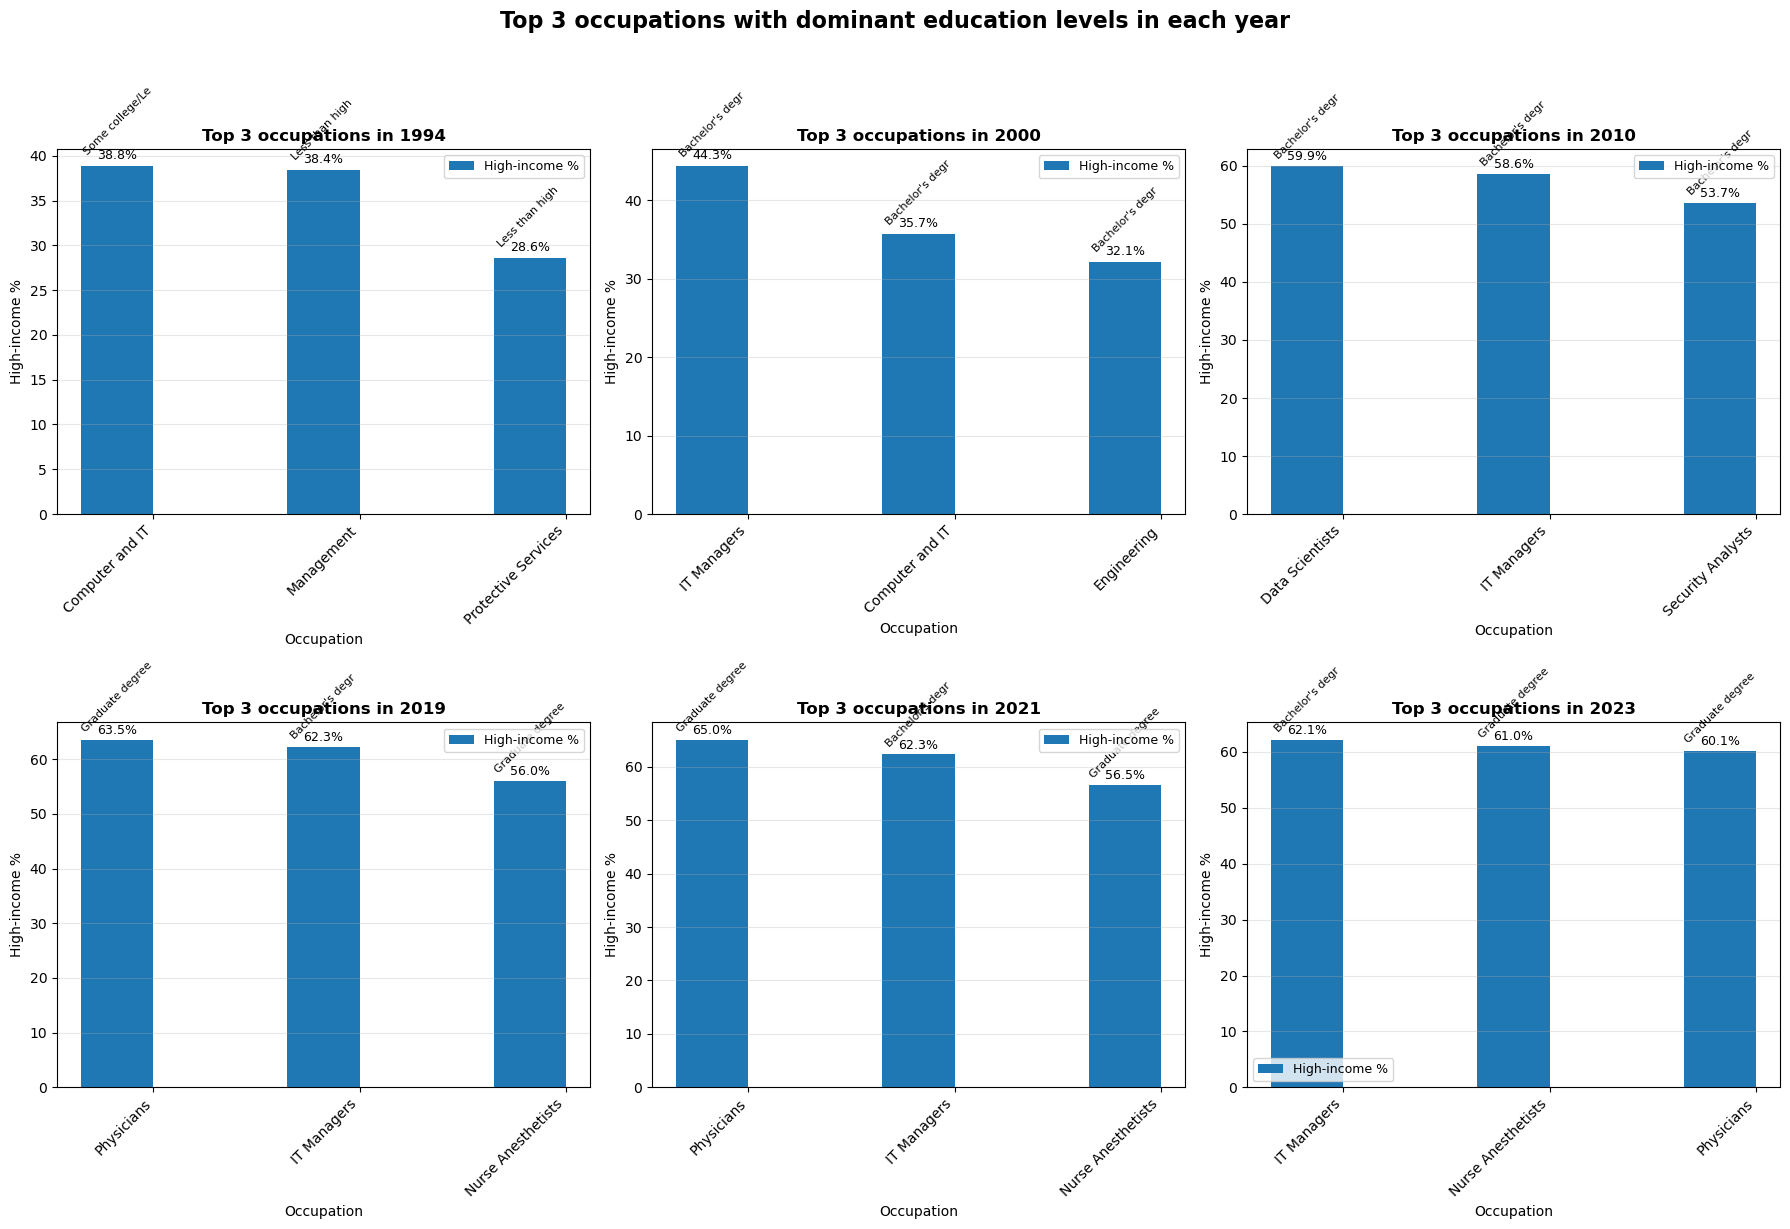

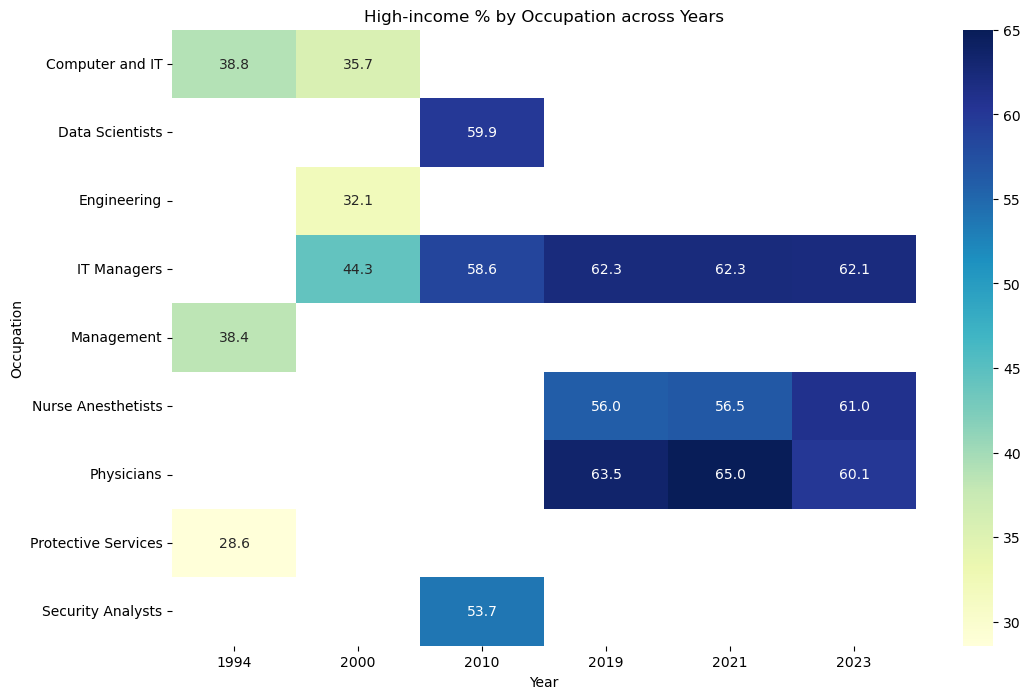

In [56]:
def compare_top_occupations_with_education():
    """
    Compare the top 3 occupations in each year with education levels
    """
    import pandas as pd

    print("Comparison of the top 3 occupations in each year with education levels")
    print("=" * 80)
    
    all_years_comparison = []
    results = []  # to collect for DataFrame
    
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year]
        
        if not all(col in df.columns for col in ['occupation_en', 'income_high_unified', 'education_level_acs']):
            continue
        
        # Find top 3 occupations
        occupation_stats = []
        
        for occupation in df['occupation_en'].dropna().unique():
            subset = df[df['occupation_en'] == occupation]
            if len(subset) >= 50:  # sufficient sample
                high_pct = subset['income_high_unified'].mean() * 100
                median_income = subset['INCTOT'].median() if 'INCTOT' in subset.columns else 0
                
                # Education analysis for this occupation
                education_dist = subset['education_level_acs'].value_counts(normalize=True).head(3)
                top_educations = []
                for edu, pct in education_dist.items():
                    top_educations.append(f"{edu} ({pct*100:.1f}%)")
                
                occupation_stats.append({
                    'occupation': occupation,
                    'high_pct': high_pct,
                    'median_income': median_income,
                    'count': len(subset),
                    'top_educations': top_educations[:2]  # top 2 education levels
                })
        
        # Sort and select top 3
        occupation_stats.sort(key=lambda x: x['high_pct'], reverse=True)
        top_3 = occupation_stats[:3]
        
        if top_3:
            for i, stat in enumerate(top_3, 1):
                results.append({
                    'Year': year,
                    'Rank': i,
                    'Occupation': stat['occupation'],
                    'High-income %': stat['high_pct'],
                    'Median income': stat['median_income'],
                    'Top education levels': ", ".join(stat['top_educations'])
                })
            
            # Save for plotting
            year_data = {
                'year': year,
                'top_occupations': top_3
            }
            all_years_comparison.append(year_data)
    
    # Convert results to DataFrame for better display
    df_results = pd.DataFrame(results)
    print("\nFull Results Table:")
    print(df_results)
    
    # Plot
    if all_years_comparison:
        plot_occupation_education_comparison(all_years_comparison, df_results)
    
    return df_results


def plot_occupation_education_comparison(all_years_data, df_results):
    """
    Plot comparison of occupations and education across years
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns
    
    # Bar plots for first 6 years
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    colors = plt.cm.tab20(np.linspace(0, 1, 10))
    
    for idx, year_data in enumerate(all_years_data[:6]):  # first 6 years only
        ax = axes[idx]
        year = year_data['year']
        top_occupations = year_data['top_occupations']
        
        occupations = []
        high_pcts = []
        education_levels = []
        
        for occ in top_occupations:
            occupations.append(occ['occupation'][:20] + ("..." if len(occ['occupation']) > 20 else ""))
            high_pcts.append(occ['high_pct'])
            
            if occ['top_educations']:
                first_edu = occ['top_educations'][0]
                edu_level = first_edu.split('(')[0].strip()
                education_levels.append(edu_level[:15])
            else:
                education_levels.append("Unknown")
        
        x = np.arange(len(occupations))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, high_pcts, width,
                      label='High-income %', color=colors[0])
        
        for i, (edu, pct) in enumerate(zip(education_levels, high_pcts)):
            ax.text(i - width/2, pct + 1, edu,
                   ha='center', va='bottom', fontsize=8, rotation=45)
        
        ax.set_xlabel('Occupation', fontsize=10)
        ax.set_ylabel('High-income %', fontsize=10)
        ax.set_title(f'Top 3 occupations in {year}', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(occupations, rotation=45, ha='right')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        
        for bar, pct in zip(bars1, high_pcts):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                   f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
    
    plt.suptitle('Top 3 occupations with dominant education levels in each year',
                fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Heatmap for overview
    pivot = df_results.pivot(index="Occupation", columns="Year", values="High-income %")
    plt.figure(figsize=(12,8))
    sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".1f")
    plt.title("High-income % by Occupation across Years")
    plt.show()


# Run the comparison
df_results = compare_top_occupations_with_education()

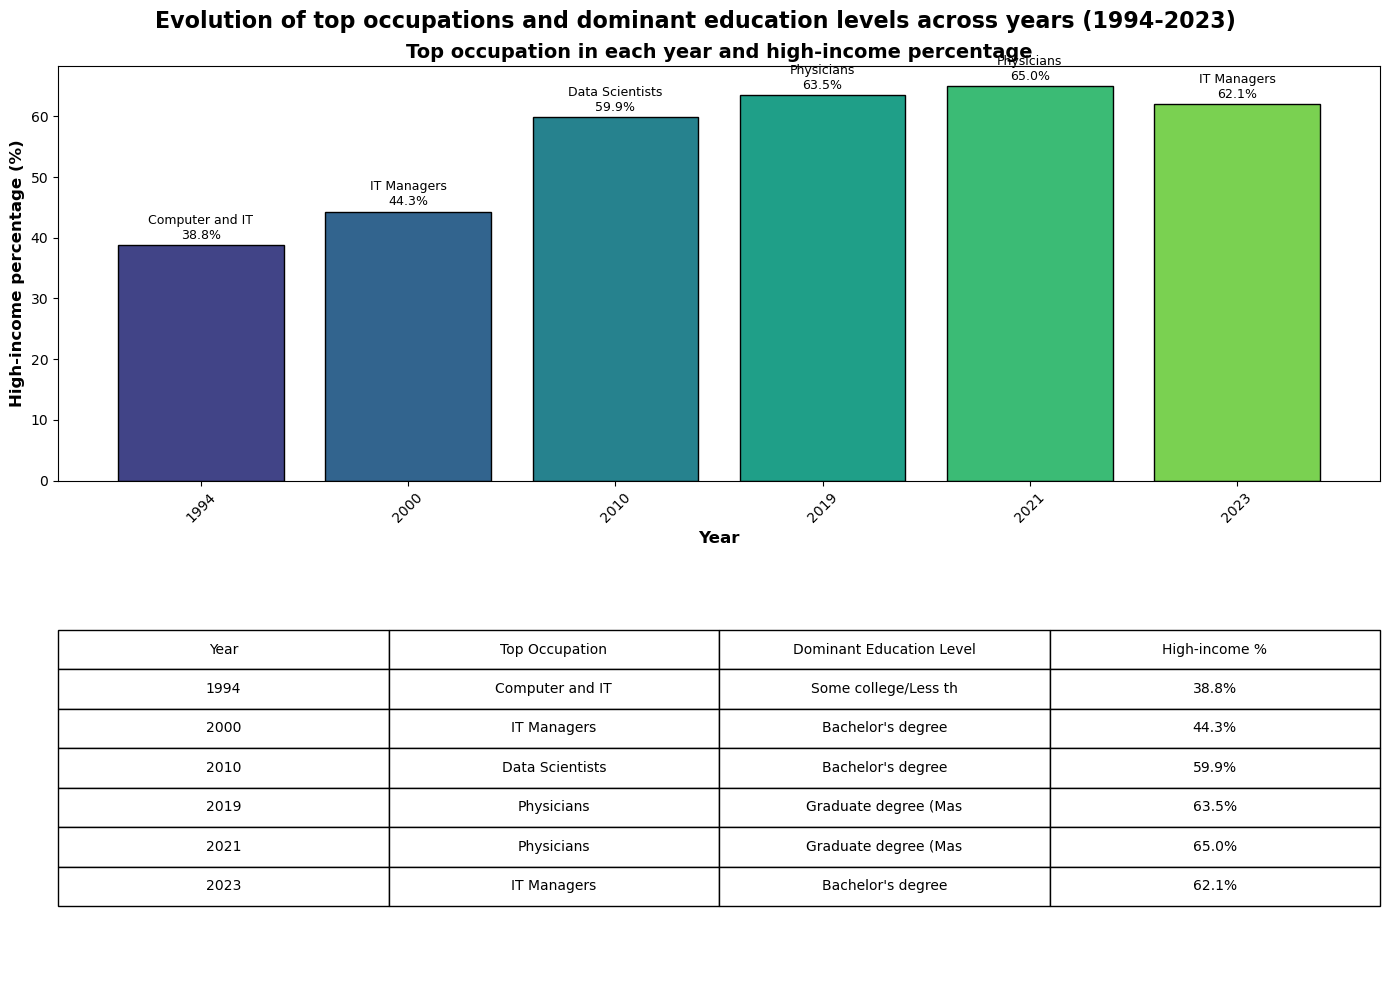


Pattern analysis of top occupations across 30 years:

Distribution of top occupations by field:
   Healthcare: 2 years (33.3%)
   Management: 2 years (33.3%)
   Technology: 1 years (16.7%)


In [52]:
def plot_top_occupation_evolution():
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Collect the top occupation in each year
    top_occupations_by_year = {}
    
    for year in sorted(six_years_data.keys()):
        df = six_years_data[year]
        
        if not all(col in df.columns for col in ['occupation_en', 'income_high_unified', 'education_level_acs']):
            continue
        
        # Find the best occupation
        best_occupation = None
        best_pct = 0
        best_education = ""
        
        for occupation in df['occupation_en'].dropna().unique():
            subset = df[df['occupation_en'] == occupation]
            if len(subset) >= 50:
                high_pct = subset['income_high_unified'].mean() * 100
                
                if high_pct > best_pct:
                    best_pct = high_pct
                    best_occupation = occupation
                    
                    # Dominant education level
                    if not subset['education_level_acs'].isna().all():
                        top_edu = subset['education_level_acs'].value_counts().index[0]
                        best_education = str(top_edu)[:20]
        
        if best_occupation:
            top_occupations_by_year[year] = {
                'occupation': best_occupation,
                'high_pct': best_pct,
                'education': best_education
            }
    
    if not top_occupations_by_year:
        return
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # Plot 1: Top occupation and high-income percentage
    years = sorted(top_occupations_by_year.keys())
    percentages = [top_occupations_by_year[y]['high_pct'] for y in years]
    occupations = [top_occupations_by_year[y]['occupation'][:25] + ("..." if len(top_occupations_by_year[y]['occupation']) > 25 else "")
                  for y in years]
    
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(years)))
    
    bars = ax1.bar(range(len(years)), percentages, color=colors, edgecolor='black')
    
    ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax1.set_ylabel('High-income percentage (%)', fontsize=12, fontweight='bold')
    ax1.set_title('Top occupation in each year and high-income percentage', fontsize=14, fontweight='bold')
    ax1.set_xticks(range(len(years)))
    ax1.set_xticklabels(years, rotation=45)
    
    # Add occupation labels
    for i, (bar, occupation) in enumerate(zip(bars, occupations)):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5,
                f'{occupation}\n{height:.1f}%',
                ha='center', va='bottom', fontsize=9)
    
    # Plot 2: Education distribution in top occupations
    ax2.axis('off')  # Hide axes
    
    # Create table
    cell_text = []
    for year in years:
        occupation = top_occupations_by_year[year]['occupation'][:30]
        education = top_occupations_by_year[year]['education']
        pct = top_occupations_by_year[year]['high_pct']
        cell_text.append([str(year), occupation, education, f"{pct:.1f}%"])
    
    table = ax2.table(cellText=cell_text,
                     colLabels=['Year', 'Top Occupation', 'Dominant Education Level', 'High-income %'],
                     cellLoc='center',
                     loc='center')
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    plt.suptitle('Evolution of top occupations and dominant education levels across years (1994-2023)',
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Pattern analysis
    print("\nPattern analysis of top occupations across 30 years:")
    print("=" * 80)
    
    # Categorize occupations by field
    occupation_categories = {
        'Healthcare': ['doctor', 'physician', 'surgeon', 'medical', 'health'],
        'Technology': ['computer', 'software', 'IT', 'engineer', 'developer'],
        'Management': ['manager', 'executive', 'director', 'administrator'],
        'Law': ['lawyer', 'attorney', 'legal'],
        'Education': ['professor', 'teacher', 'educator'],
        'Finance': ['financial', 'accountant', 'analyst', 'banker']
    }
    
    category_counts = {cat: 0 for cat in occupation_categories.keys()}
    
    for year, data in top_occupations_by_year.items():
        occupation_lower = data['occupation'].lower()
        
        for category, keywords in occupation_categories.items():
            if any(keyword in occupation_lower for keyword in keywords):
                category_counts[category] += 1
                break
    
    print("\nDistribution of top occupations by field:")
    for category, count in sorted(category_counts.items(), key=lambda x: x[1], reverse=True):
        if count > 0:
            percentage = (count / len(top_occupations_by_year)) * 100
            print(f"   {category}: {count} years ({percentage:.1f}%)")
plot_top_occupation_evolution()

In [59]:
import os

output_folder = "six_years_data_final"
os.makedirs(output_folder, exist_ok=True)

for year, df in six_years_data.items():
    output_file = os.path.join(output_folder, f"year_{year}_final.csv")
    df.to_csv(output_file, index=False, encoding="utf-8")
    print(f"Saved {year}: {len(df)} rows, {len(df.columns)} columns → {output_file}")

Saved 1994: 19972 rows, 23 columns → six_years_data_final\year_1994_final.csv
Saved 2000: 128646 rows, 22 columns → six_years_data_final\year_2000_final.csv
Saved 2010: 5118672 rows, 22 columns → six_years_data_final\year_2010_final.csv
Saved 2019: 5311296 rows, 22 columns → six_years_data_final\year_2019_final.csv
Saved 2021: 5230362 rows, 22 columns → six_years_data_final\year_2021_final.csv
Saved 2023: 1177724 rows, 22 columns → six_years_data_final\year_2023_final.csv
